# Master Analysis — SpaceX Reliability Study

**Pergunta de pesquisa**: A reutilização de foguetes afeta a confiabilidade das missões?

Neste notebook, reunimos os resultados das análises individuais feitas por cada membro da equipe. O objetivo é ter uma visão consolidada dos achados antes de redigir o relatório final.

| Analista | Foco |
|----------|------|
| Gabriel | Tendências temporais |
| Kaio | Impacto da reutilização |
| Izac | Experiência do booster |
| Jonatas | Famílias de foguetes |

Os notebooks originais com as análises exploratórias estão em `analyses/`.

In [1]:
import pandas as pd
from IPython.display import Image, display, Markdown

## 1. Visão Geral do Dataset

Os dados foram extraídos da SpaceX API v4 e tratados no notebook `lucas_data_extraction.ipynb`. Um ponto importante: cada linha do dataset representa um **booster individual**, não um lançamento. Isso quer dizer que missões do Falcon Heavy (que usa 3 boosters) geram 3 linhas no dataset.

In [2]:
df = pd.read_csv('../data/processed/processed_dataset_v1.csv')

print('=' * 60)
print('VISÃO GERAL DO DATASET')
print('=' * 60)
print(f'Registros: {df.shape[0]} | Variáveis: {df.shape[1]}')

year_min = df['launch_year'].min()
year_max = df['launch_year'].max()
print(f'Período: {year_min} - {year_max}')

success_rate = df['success'].mean() * 100
total_success = df['success'].sum()
total = len(df)
print(f'Taxa de Sucesso Global: {success_rate:.2f}%')
print(f'Missões bem-sucedidas: {total_success} de {total}')
print()

reused_count = df['is_reused'].sum()
virgin_count = (~df['is_reused']).sum()
reused_pct = df['is_reused'].mean() * 100
virgin_pct = (~df['is_reused']).mean() * 100
print('Distribuição por tipo de booster:')
print(f'  Reutilizados: {reused_count} ({reused_pct:.1f}%)')
print(f'  Virgens:      {virgin_count} ({virgin_pct:.1f}%)')
print()

print('Distribuição por família de foguete:')
for name, count in df['rocket_name'].value_counts().items():
    print(f'  {name}: {count} registros')
print()

rc_min = df['reuse_count'].min()
rc_max = df['reuse_count'].max()
rc_mean = df['reuse_count'].mean()
print('Estatísticas de reuse_count:')
print(f'  Mín: {rc_min} | Máx: {rc_max} | Média: {rc_mean:.1f}')
print('=' * 60)

display(Markdown('### Primeiras linhas do dataset'))
display(df.head(10))

VISÃO GERAL DO DATASET
Registros: 192 | Variáveis: 9
Período: 2006 - 2022
Taxa de Sucesso Global: 97.40%
Missões bem-sucedidas: 187 de 192

Distribuição por tipo de booster:
  Reutilizados: 149 (77.6%)
  Virgens:      43 (22.4%)

Distribuição por família de foguete:
  Falcon 9: 178 registros
  Falcon Heavy: 9 registros
  Falcon 1: 5 registros

Estatísticas de reuse_count:
  Mín: 0 | Máx: 13 | Média: 5.1


### Primeiras linhas do dataset

,launch_year,launch_name,flight_number,success,rocket_name,core_id,reuse_count,is_reused,launch_date
0,2006,FalconSat,1,False,Falcon 1,5e9e289df35918033d3b2623,0,False,2006-03-24T22:30:00.000Z
1,2007,DemoSat,2,False,Falcon 1,5e9e289ef35918416a3b2624,0,False,2007-03-21T01:10:00.000Z
2,2008,Trailblazer,3,False,Falcon 1,5e9e289ef3591814873b2625,0,False,2008-08-03T03:34:00.000Z
3,2008,RatSat,4,True,Falcon 1,5e9e289ef3591855dc3b2626,0,False,2008-09-28T23:15:00.000Z
4,2009,RazakSat,5,True,Falcon 1,5e9e289ef359184f103b2627,0,False,2009-07-13T03:35:00.000Z
5,2010,Falcon 9 Test Flight,6,True,Falcon 9,5e9e289ef359185f2b3b2628,0,False,2010-06-04T18:45:00.000Z
6,2010,COTS 1,7,True,Falcon 9,5e9e289ef35918187c3b2629,0,False,2010-12-08T15:43:00.000Z
7,2012,COTS 2,8,True,Falcon 9,5e9e289ef35918f39c3b262a,0,False,2012-05-22T07:44:00.000Z
8,2012,CRS-1,9,True,Falcon 9,5e9e289ff3591821a73b262b,0,False,2012-10-08T00:35:00.000Z
9,2013,CRS-2,10,True,Falcon 9,5e9e289ff3591884e03b262c,0,False,2013-03-01T19:10:00.000Z


---

## 2. Análise Temporal — Gabriel

Gabriel investigou como a taxa de sucesso dos lançamentos mudou ao longo dos anos, de 2006 a 2022. Ele calculou as taxas anuais com intervalos de confiança de 95%.

### Estatísticas Anuais

,launch_year,total_launches,successful_launches,reused_boosters,success_rate,reuse_rate,ci_lower,ci_upper
0,2006,1,0,0,0.0000,0.0000,0.0000,79.3451
1,2007,1,0,0,0.0000,0.0000,0.0000,79.3451
2,2008,2,1,0,50.0000,0.0000,9.4531,90.5469
3,2009,1,1,0,100.0000,0.0000,20.6549,100.0000
4,2010,2,2,0,100.0000,0.0000,34.2380,100.0000
5,2012,2,2,0,100.0000,0.0000,34.2380,100.0000
6,2013,3,3,0,100.0000,0.0000,43.8503,100.0000
7,2014,6,6,0,100.0000,0.0000,60.9666,100.0000
8,2015,7,6,0,85.7143,0.0000,48.6872,97.4320
9,2016,9,8,3,88.8889,33.3333,56.5000,98.0109


### Lançamentos por Ano

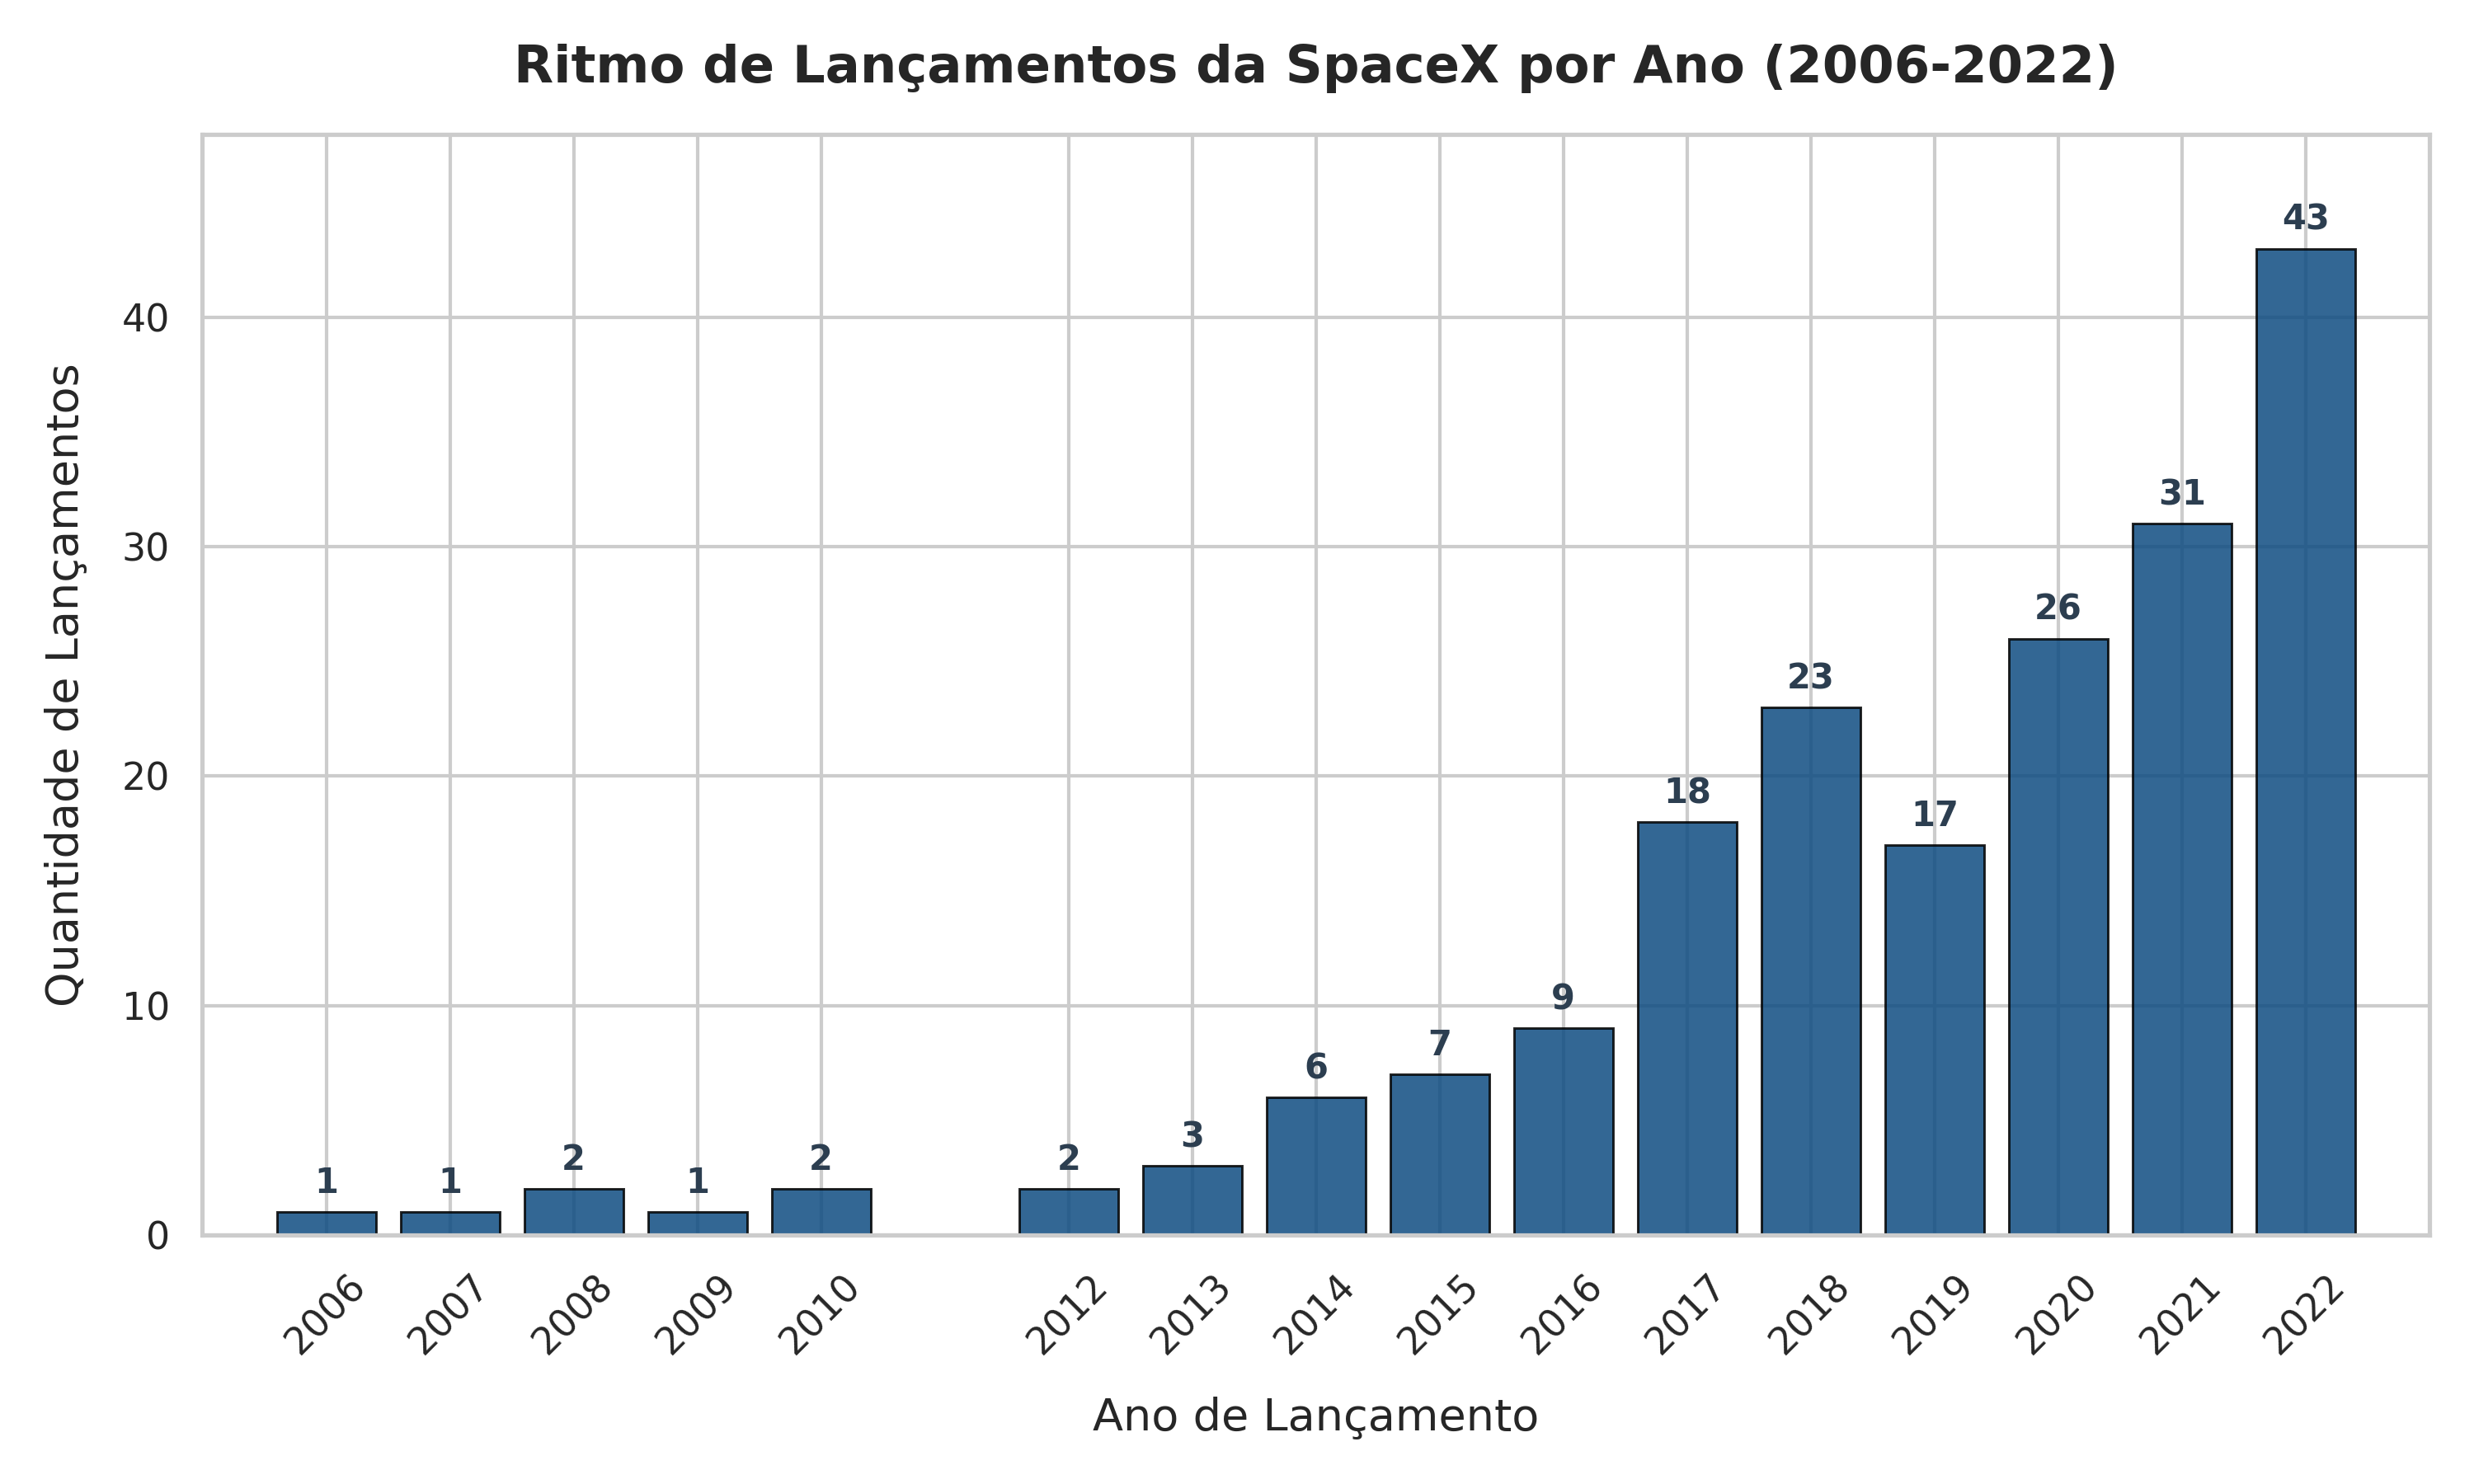

### Taxa de Sucesso por Ano

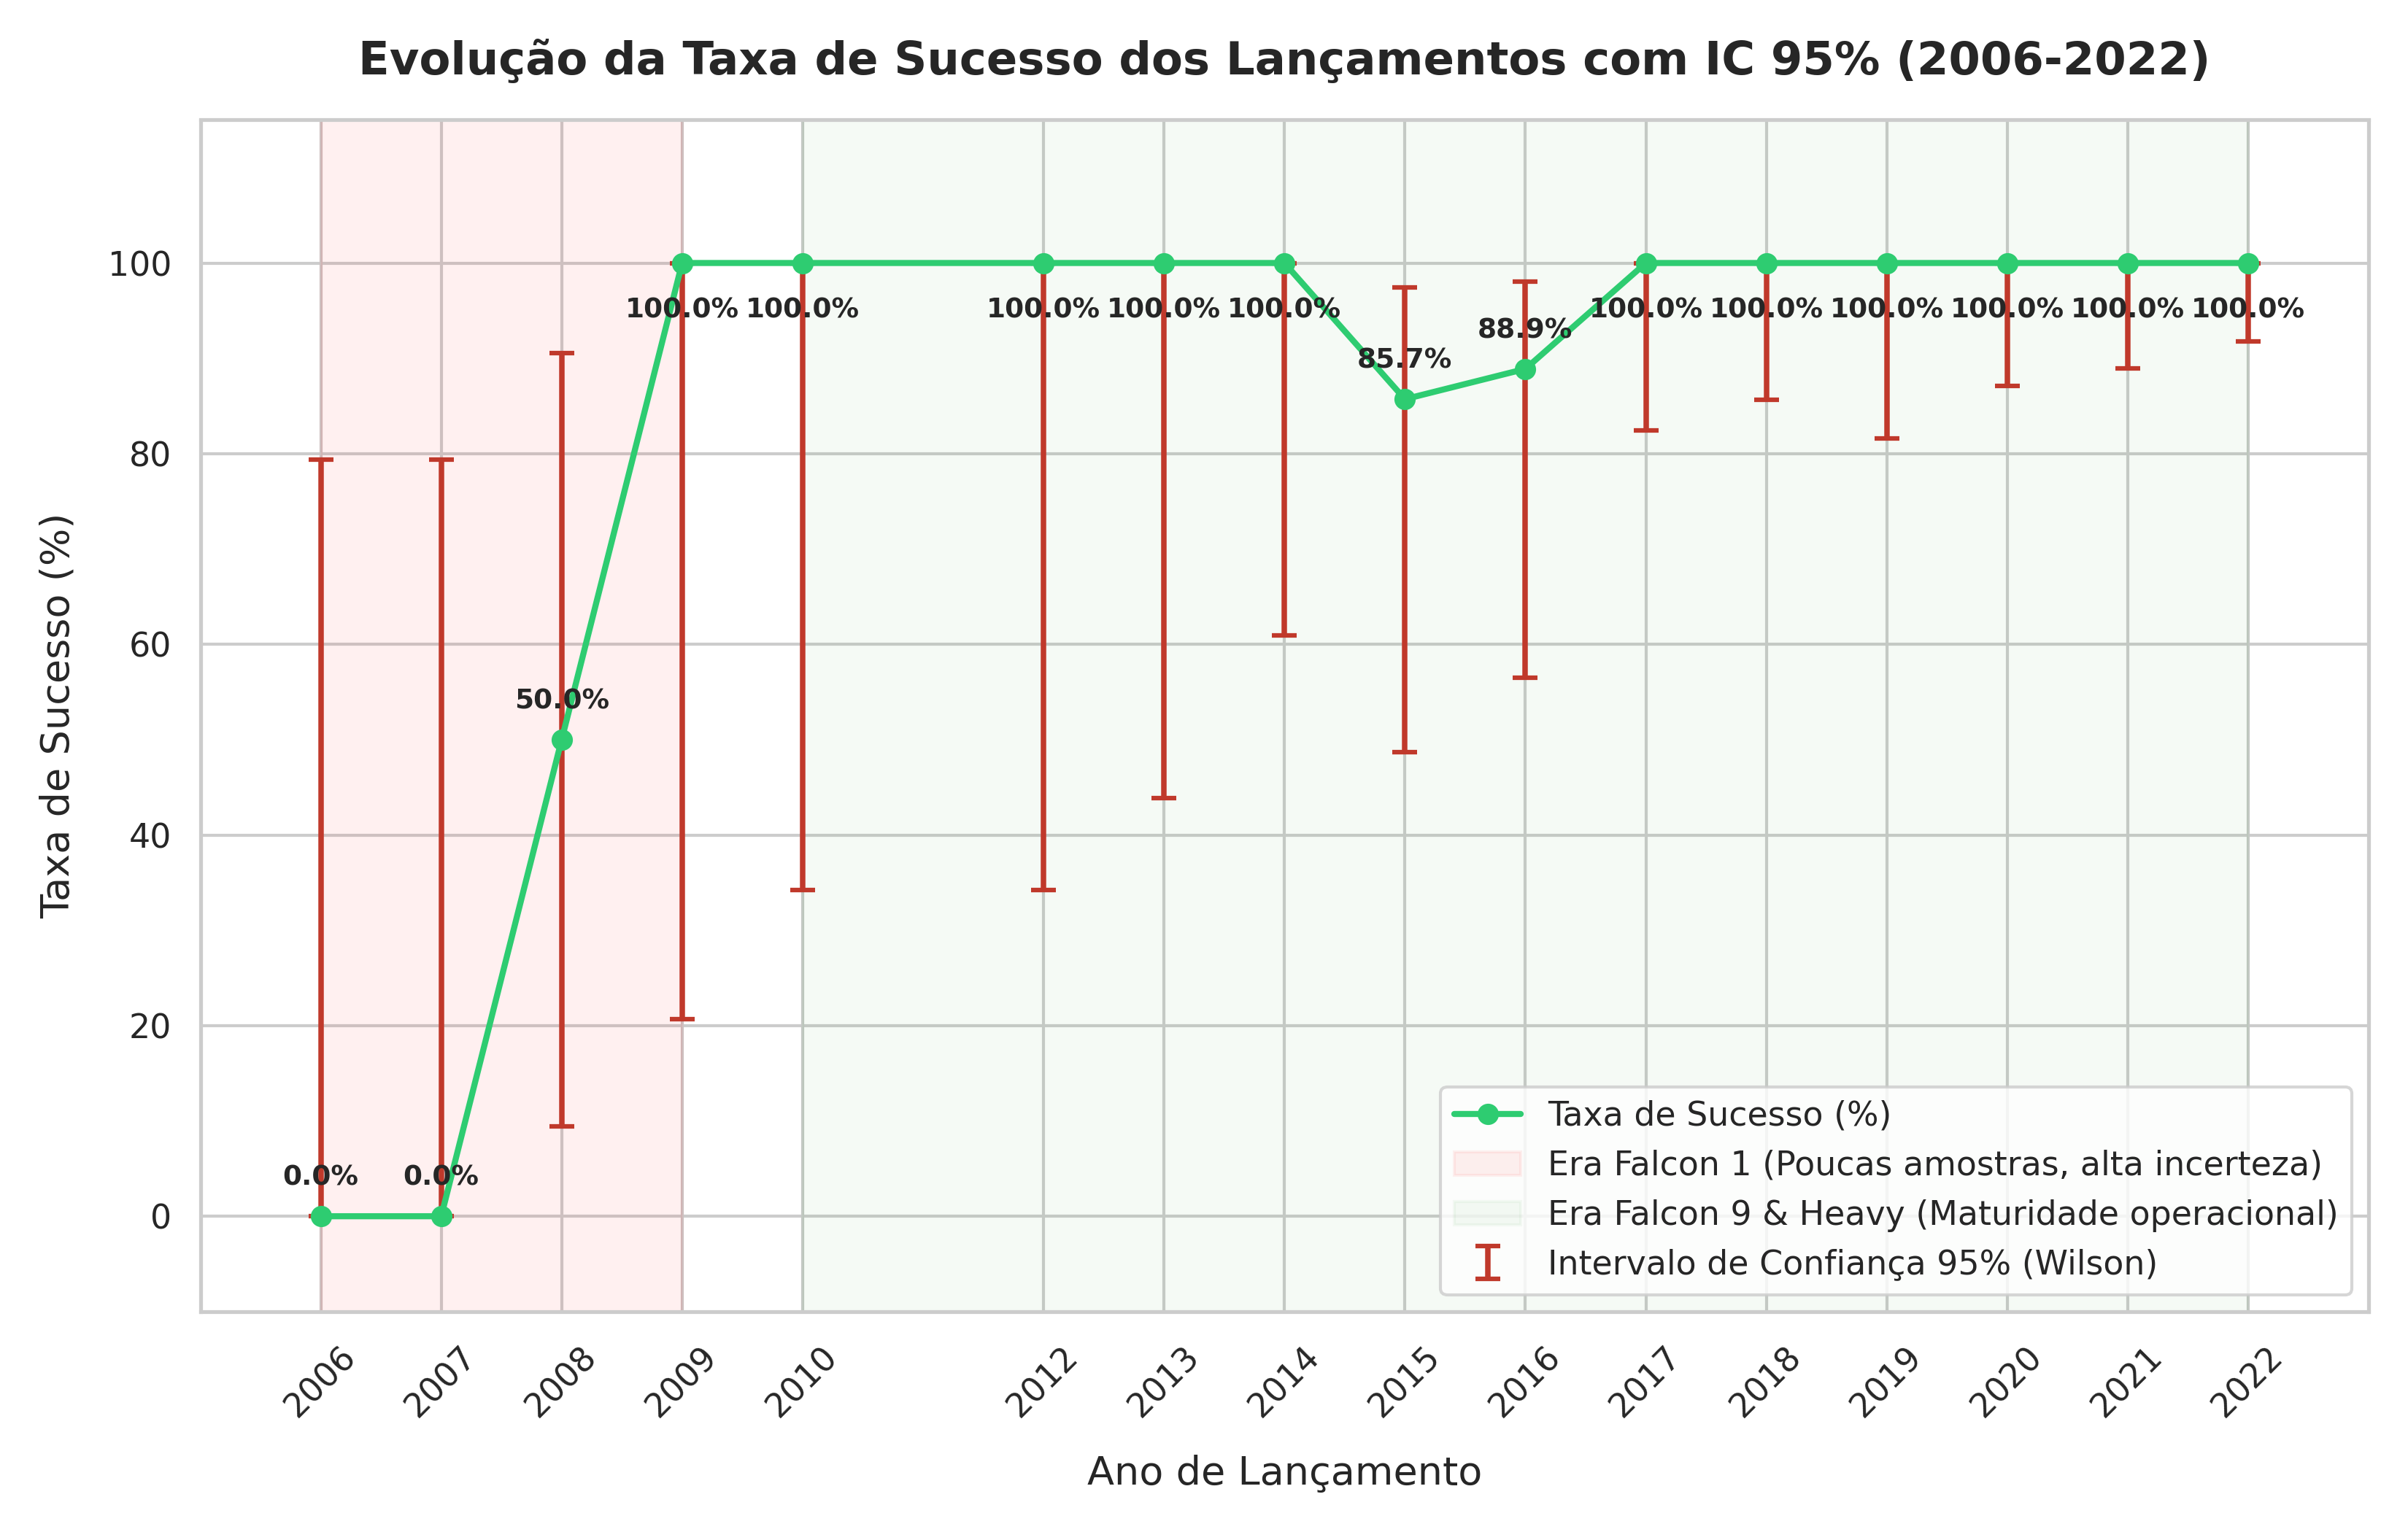

### Taxa de Reutilização por Ano

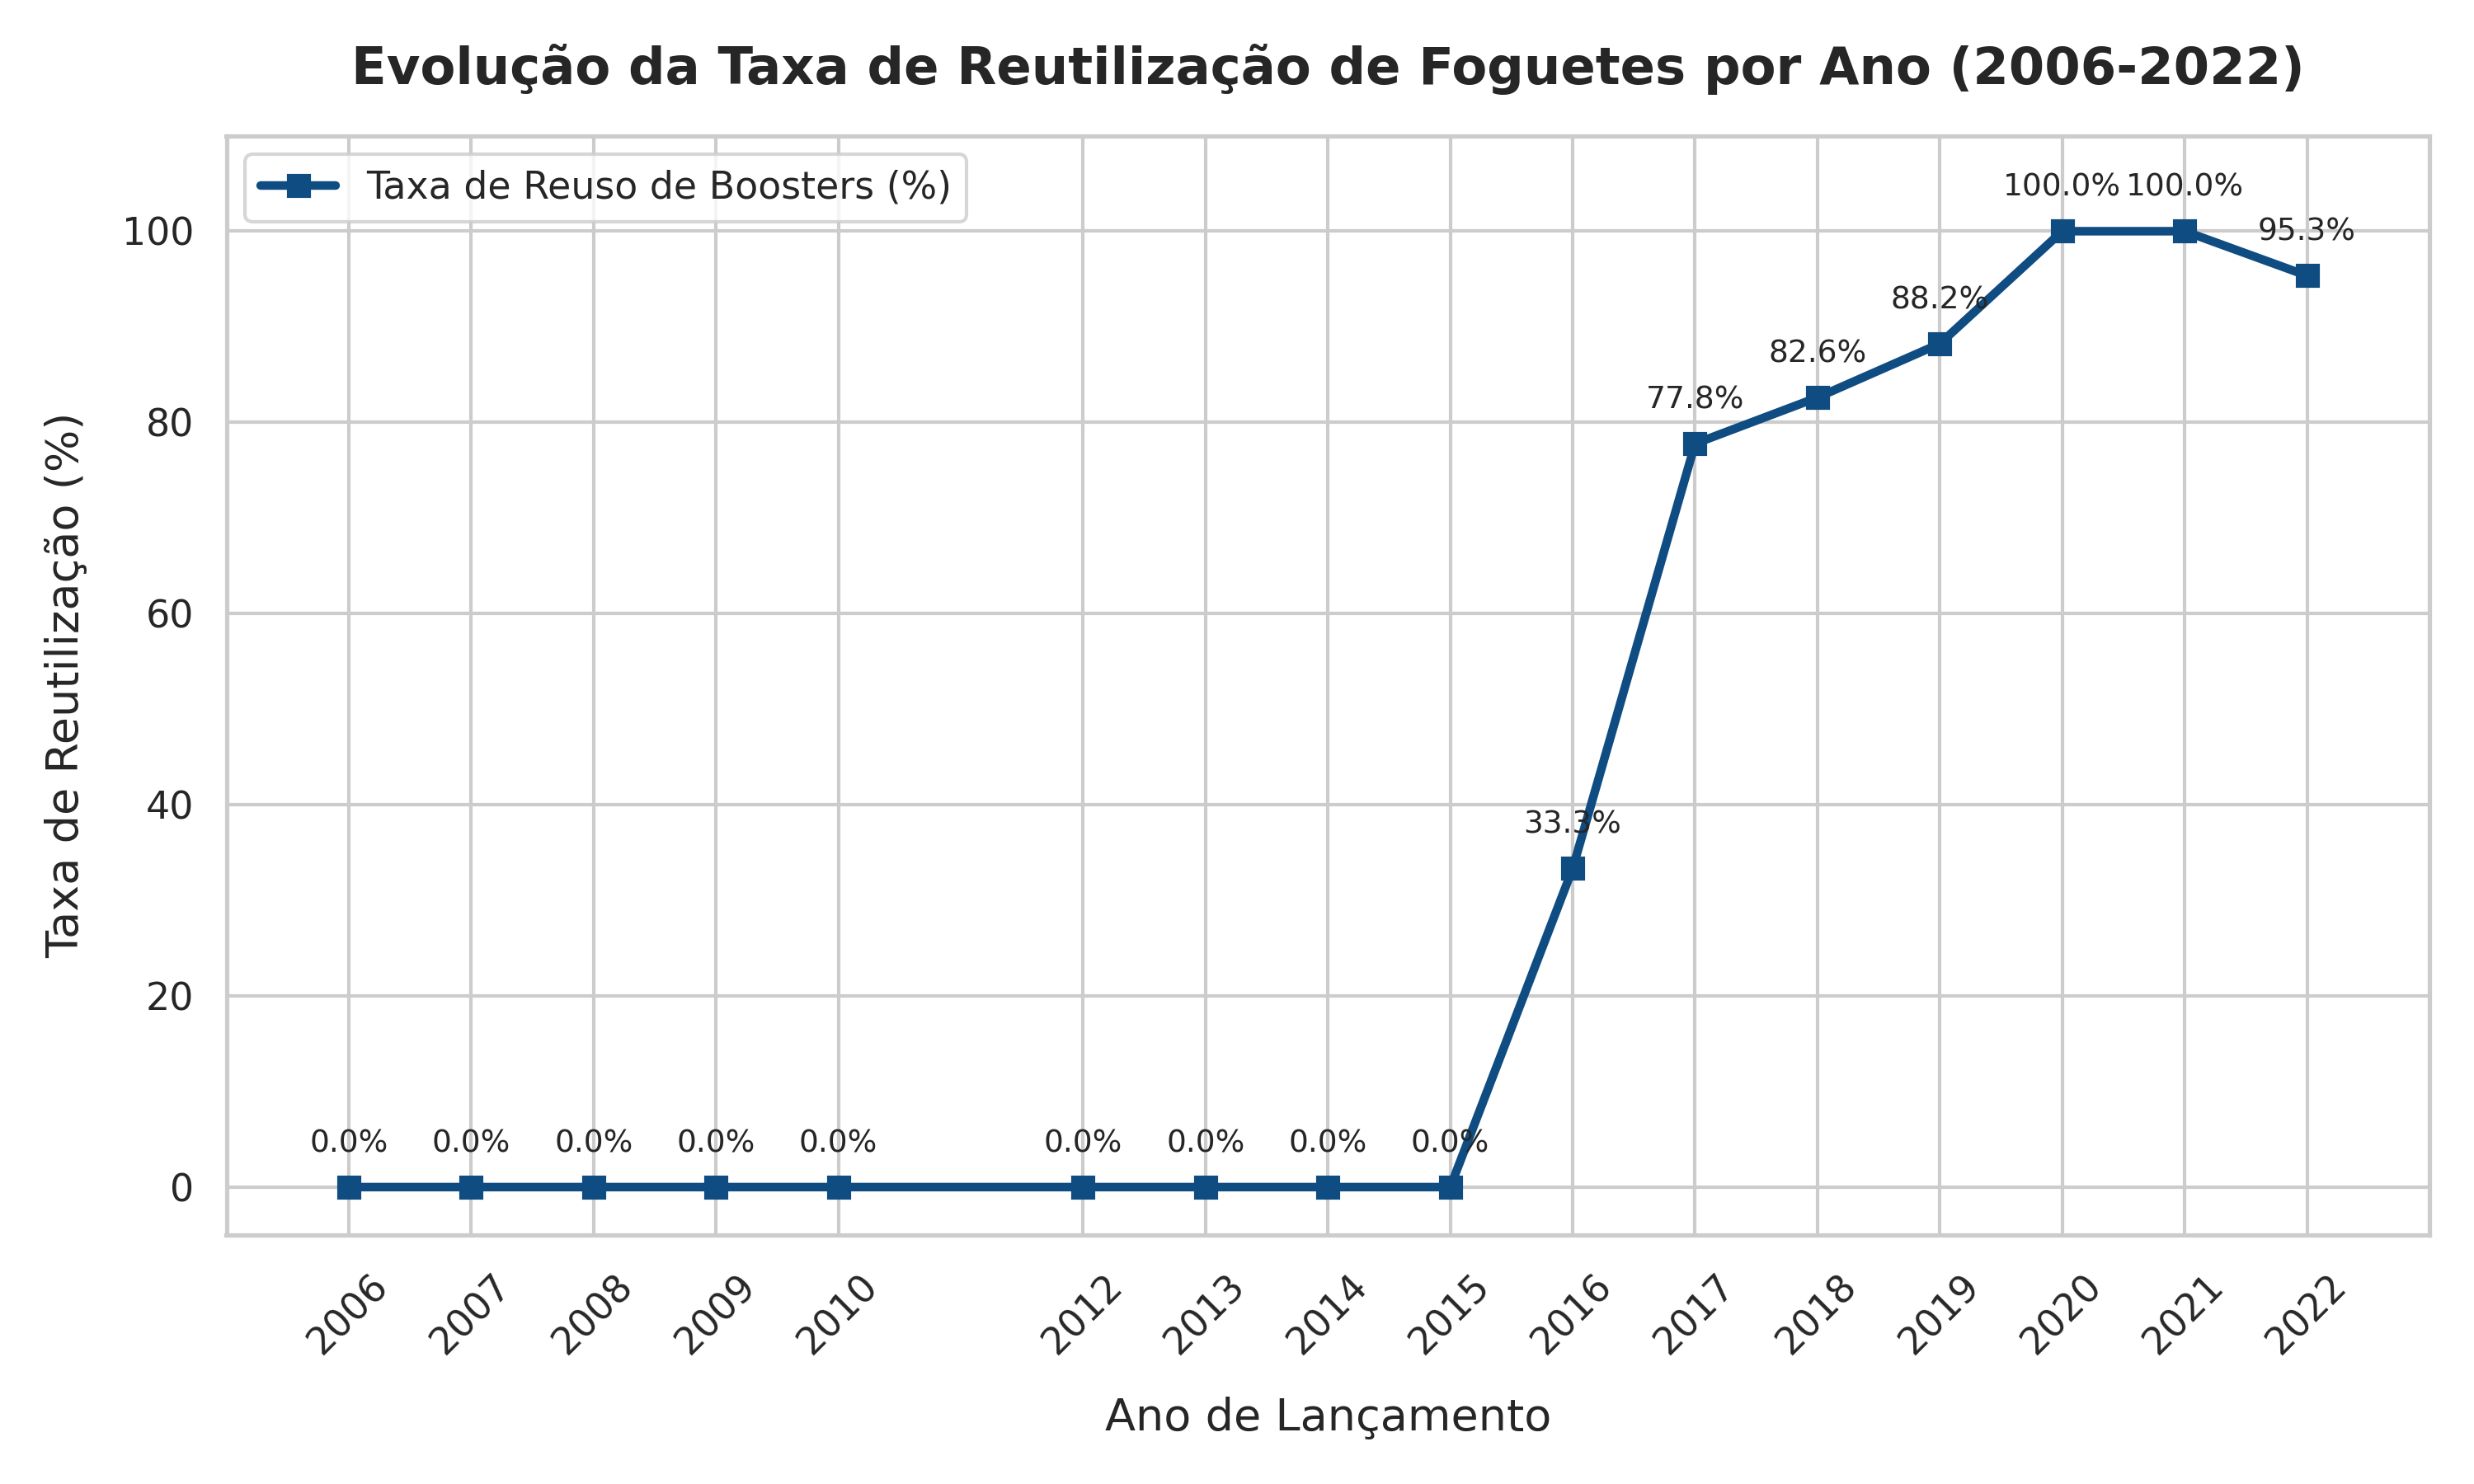

### Composição de Foguetes por Ano

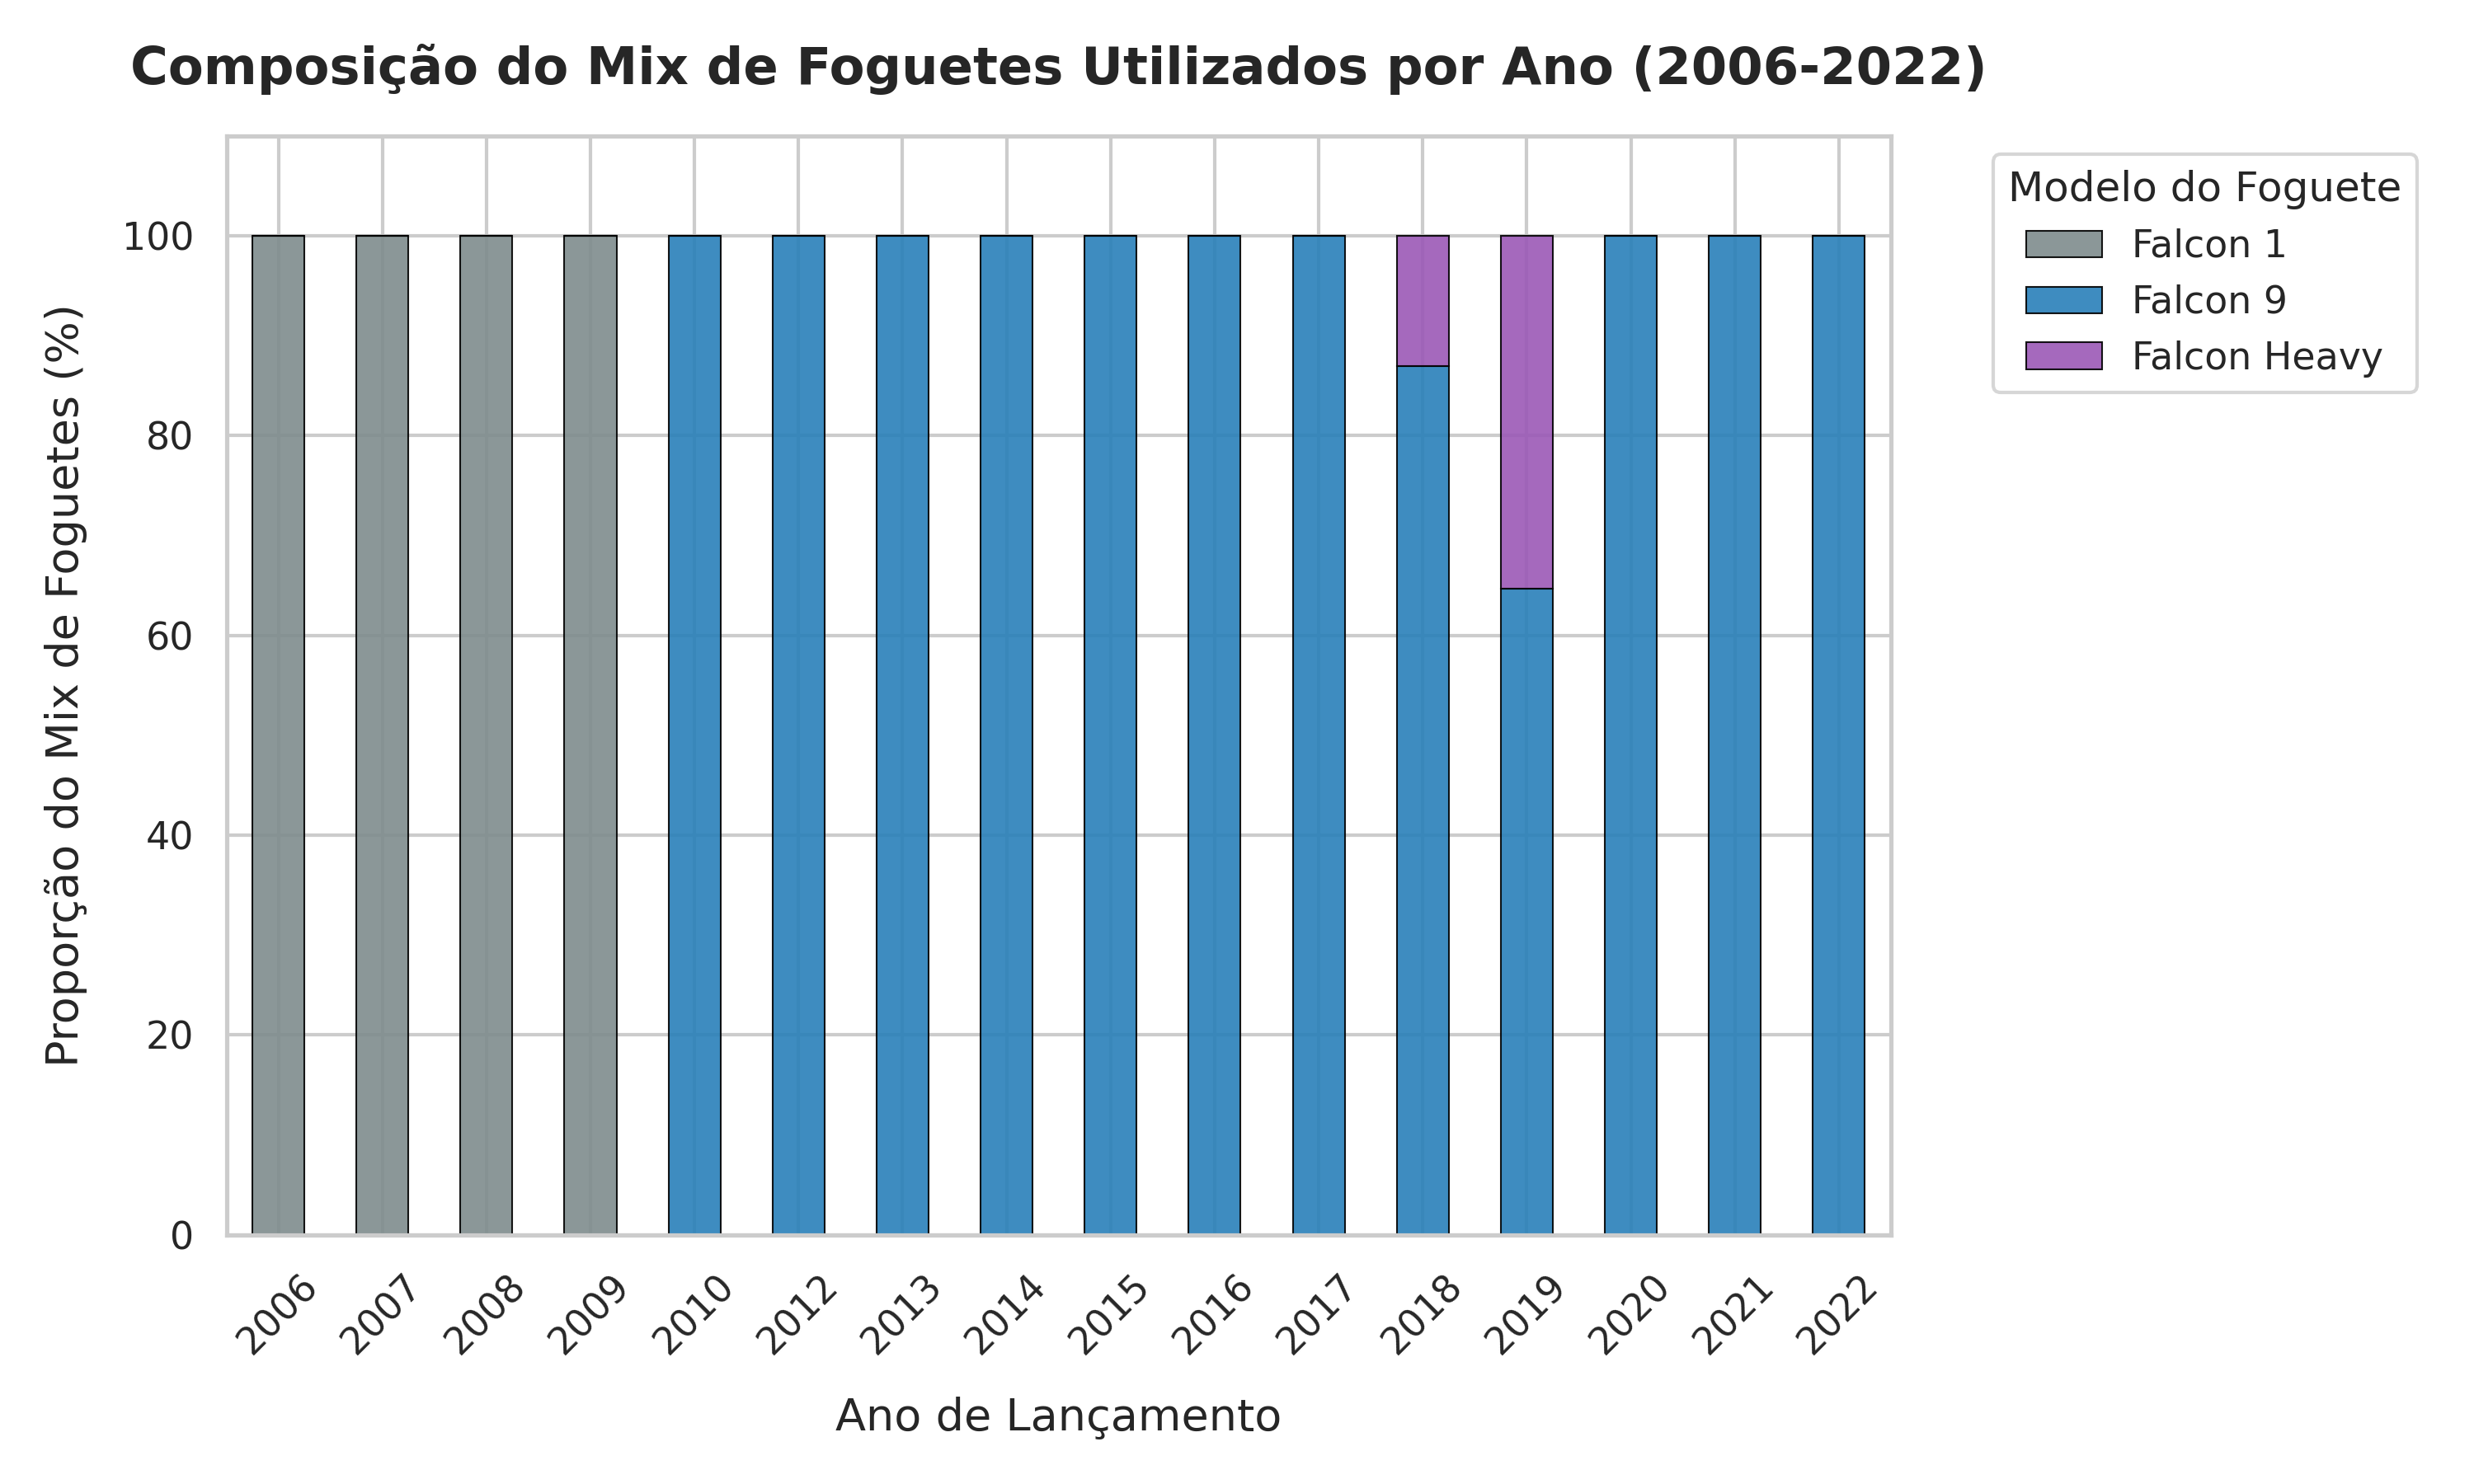

In [3]:
gabriel_stats = pd.read_csv('../analyses/gabriel/yearly_stats.csv')
display(Markdown('### Estatísticas Anuais'))
display(gabriel_stats)

display(Markdown('### Lançamentos por Ano'))
display(Image(filename='../graphs/gabriel_launches_per_year.png', width=700))

display(Markdown('### Taxa de Sucesso por Ano'))
display(Image(filename='../graphs/gabriel_success_rate_per_year.png', width=700))

display(Markdown('### Taxa de Reutilização por Ano'))
display(Image(filename='../graphs/gabriel_reuse_rate_per_year.png', width=700))

display(Markdown('### Composição de Foguetes por Ano'))
display(Image(filename='../graphs/gabriel_rocket_mix_per_year.png', width=700))

### O que os dados mostram

A evolução é bem visível nos gráficos: nos primeiros anos (2006-2008), a SpaceX ainda estava aprendendo com o Falcon 1 e a taxa de sucesso era baixa. A partir de 2010, com a entrada do Falcon 9, a coisa mudou de figura — a taxa subiu para perto de 100% e se manteve lá.

Outro ponto interessante é o crescimento no número de lançamentos: saiu de 1-2 por ano para 43 em 2022, sem que isso prejudicasse a confiabilidade. A reutilização também acompanhou esse crescimento, saindo de zero para praticamente 100% dos boosters em 2020.

Um cuidado importante: parte dessa melhoria pode ser simplesmente porque a SpaceX trocou de foguete (do Falcon 1 para o Falcon 9), e não necessariamente por aprendizado operacional. Esse confundidor temporal aparece em várias das nossas análises.

---

## 3. Impacto da Reutilização — Kaio

Aqui o Kaio foi direto na pergunta central do projeto: será que reutilizar um booster compromete o sucesso da missão? Ele separou os boosters em dois grupos — virgens e reutilizados — e comparou as taxas.

### Comparação: Virgens vs Reutilizados

,Tipo,Quantidade,Sucessos,Taxa_Sucesso
0,Virgem,43,38,0.883721
1,Reutilizado,149,149,1.000000


### Taxa de Sucesso Anual por Tipo

,launch_year,Virgens,Reutilizados
0,2006,0.000000,NaN
1,2007,0.000000,NaN
2,2008,0.500000,NaN
3,2009,1.000000,NaN
4,2010,1.000000,NaN
5,2012,1.000000,NaN
6,2013,1.000000,NaN
7,2014,1.000000,NaN
8,2015,0.857143,NaN
9,2016,0.833333,1.0


### Taxa de Sucesso Global

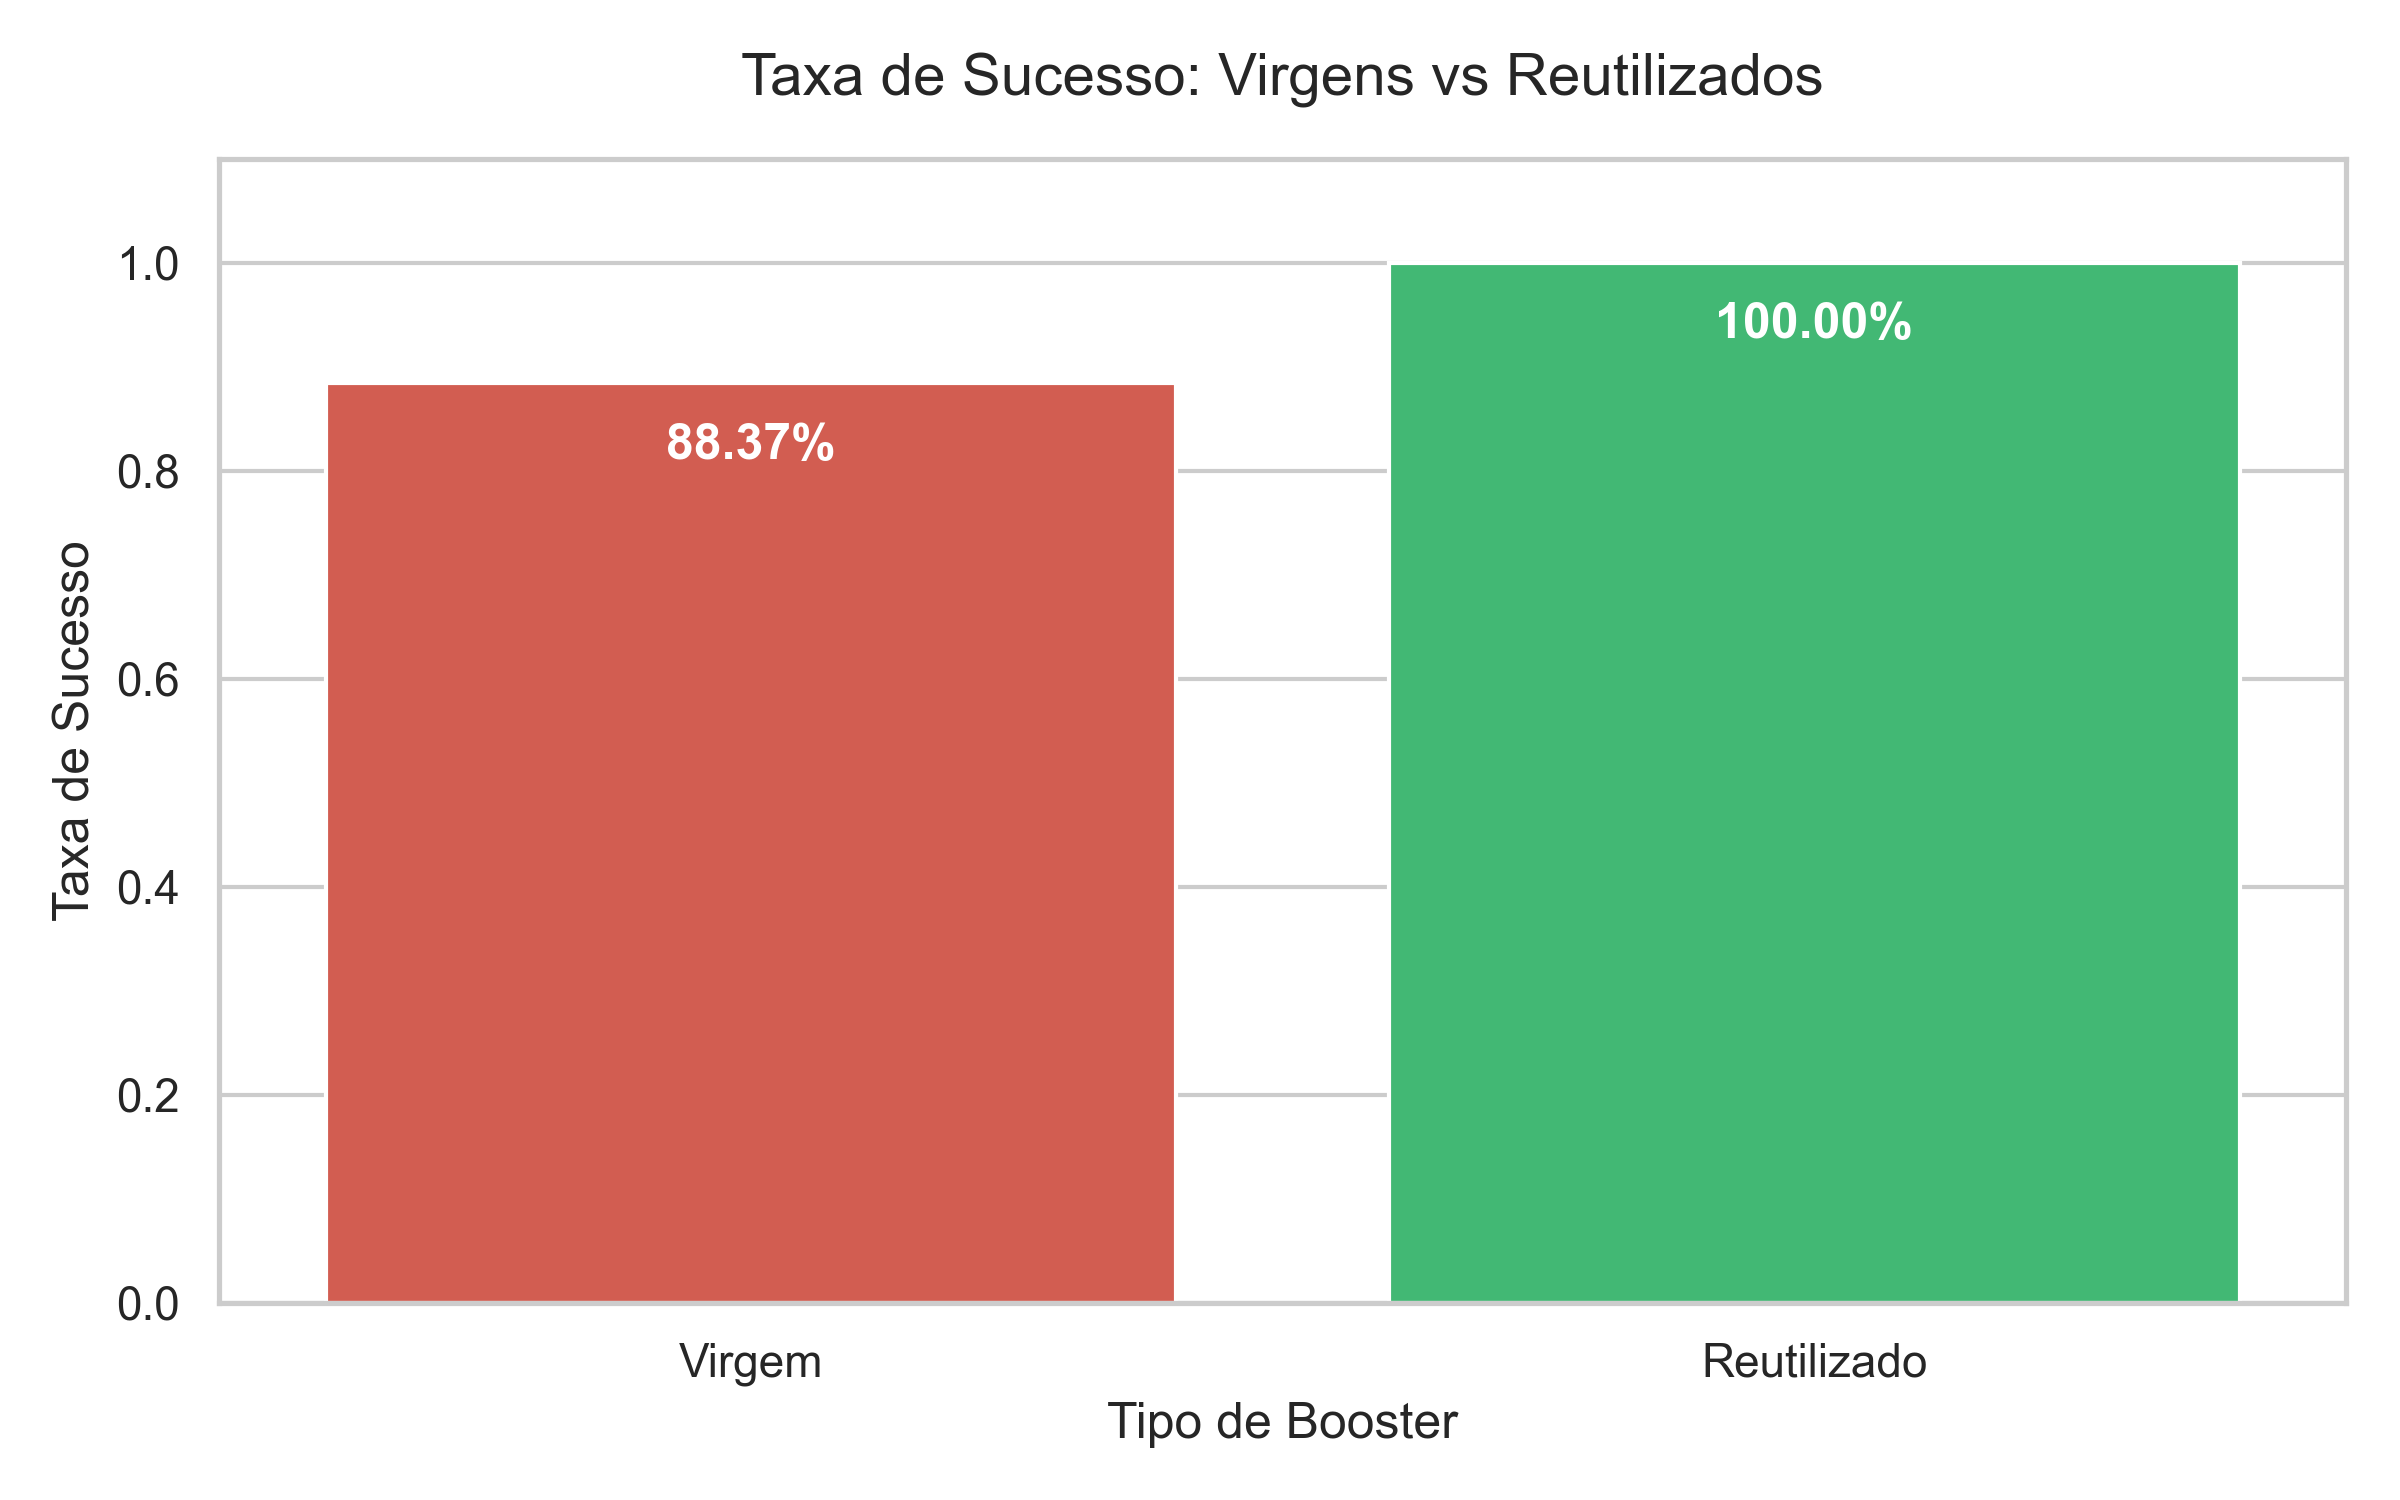

### Distribuição Temporal

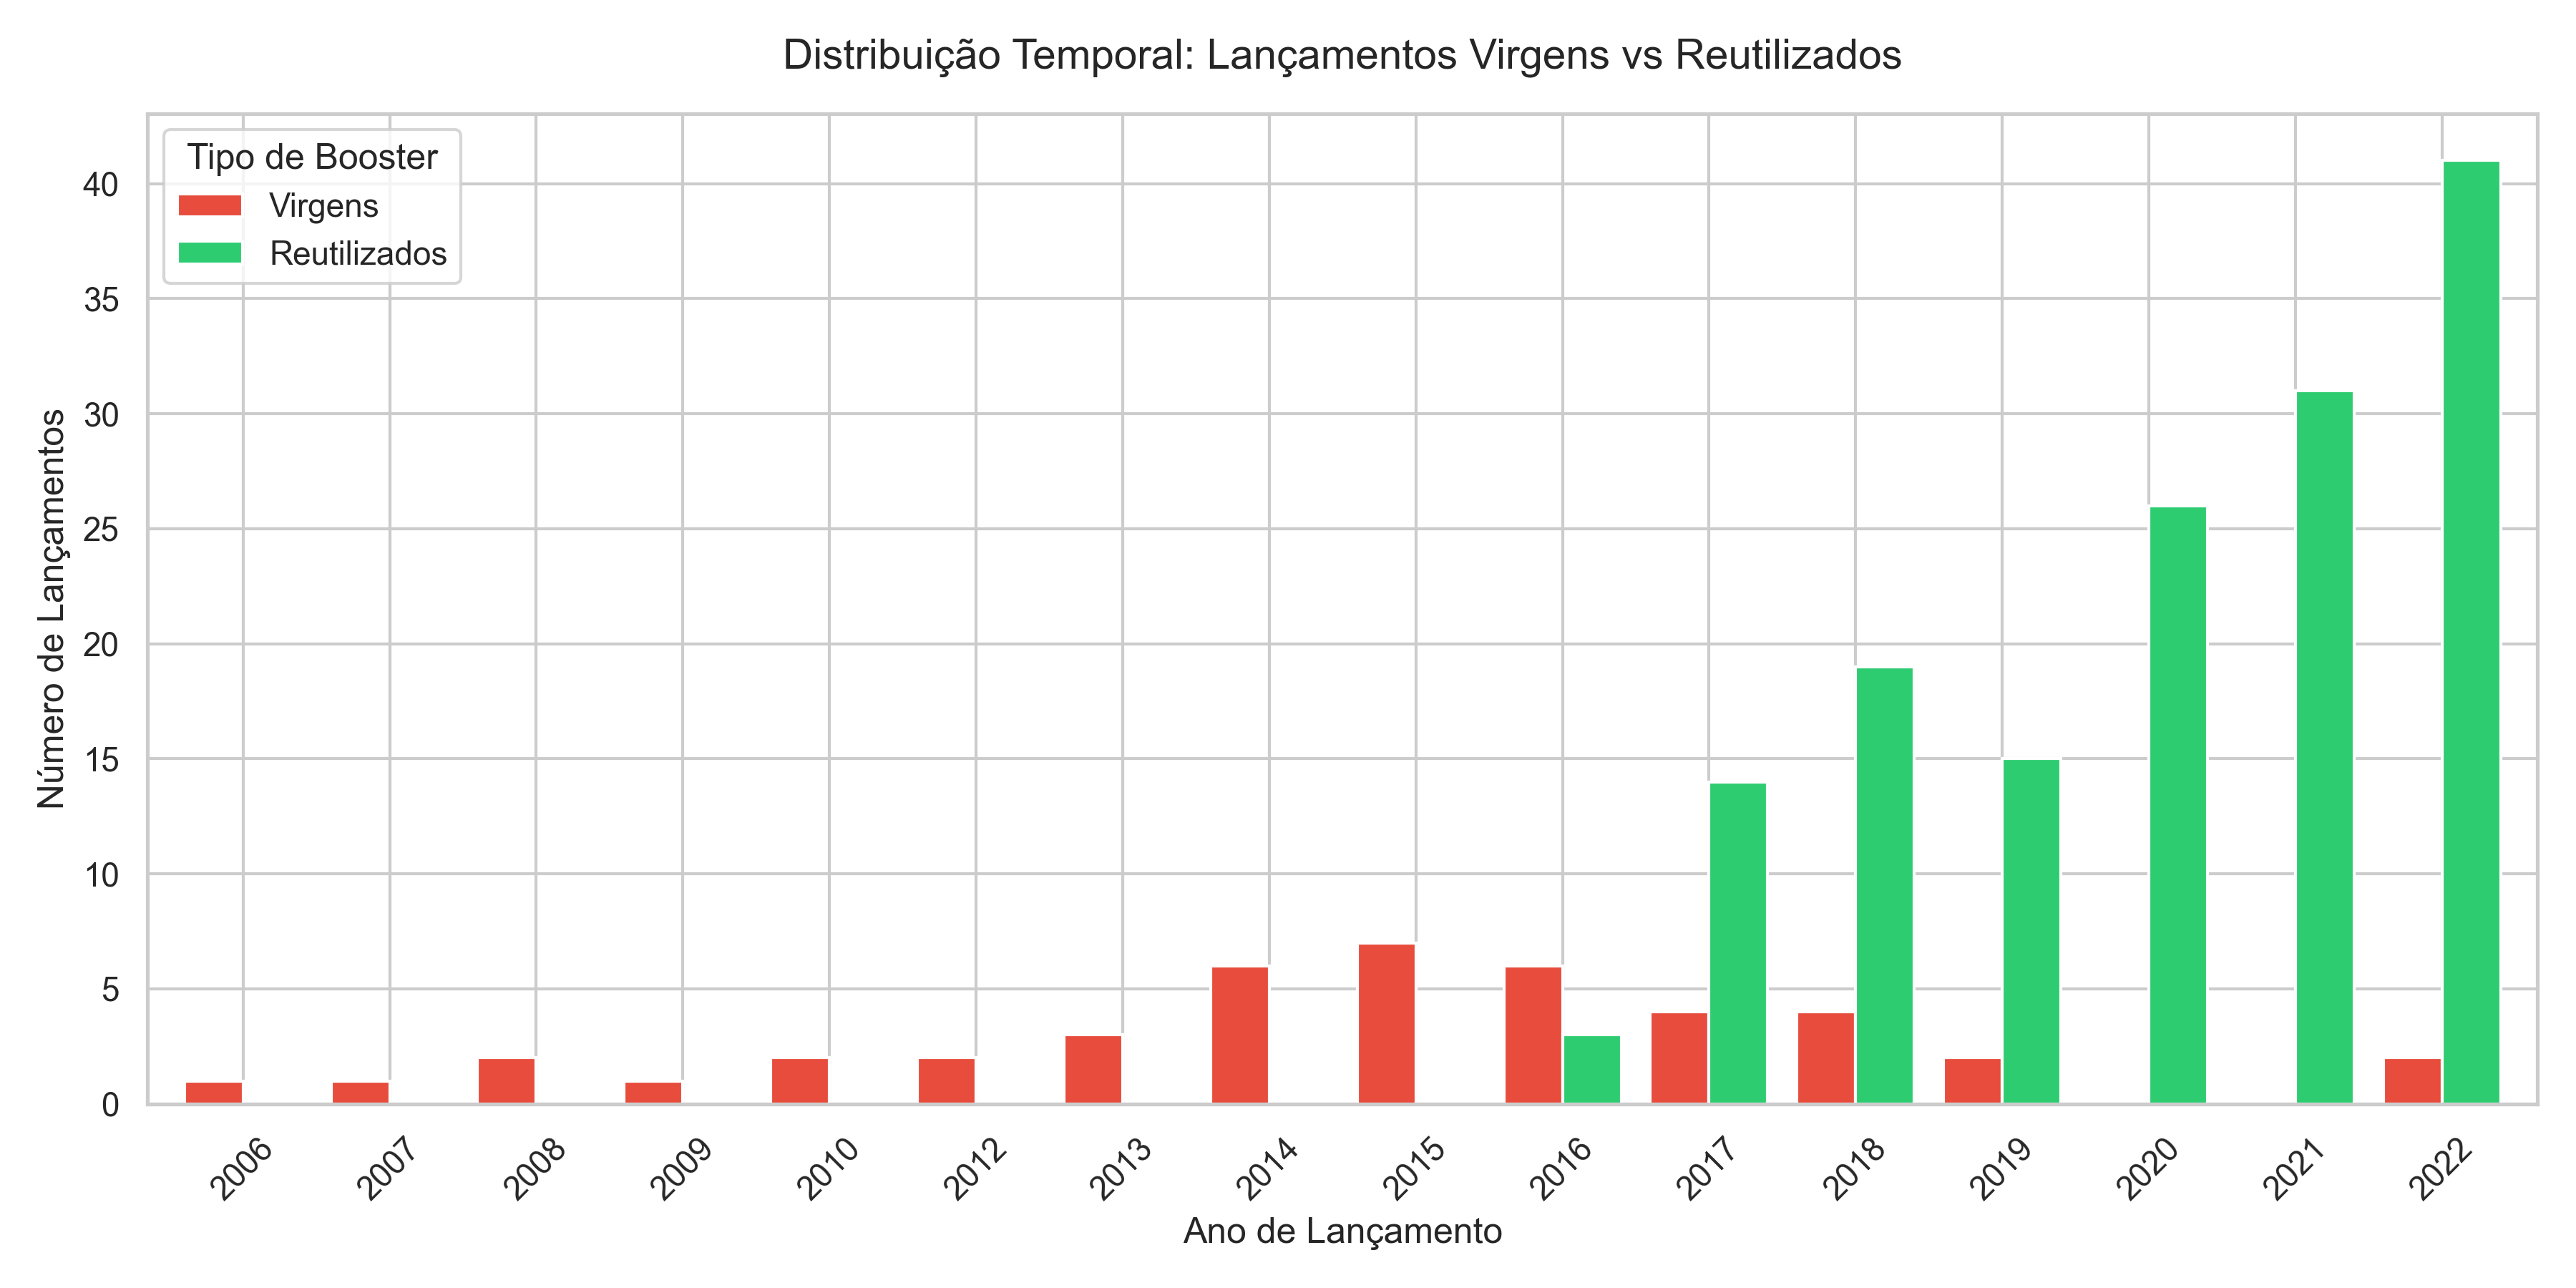

### Curva Dose-Resposta

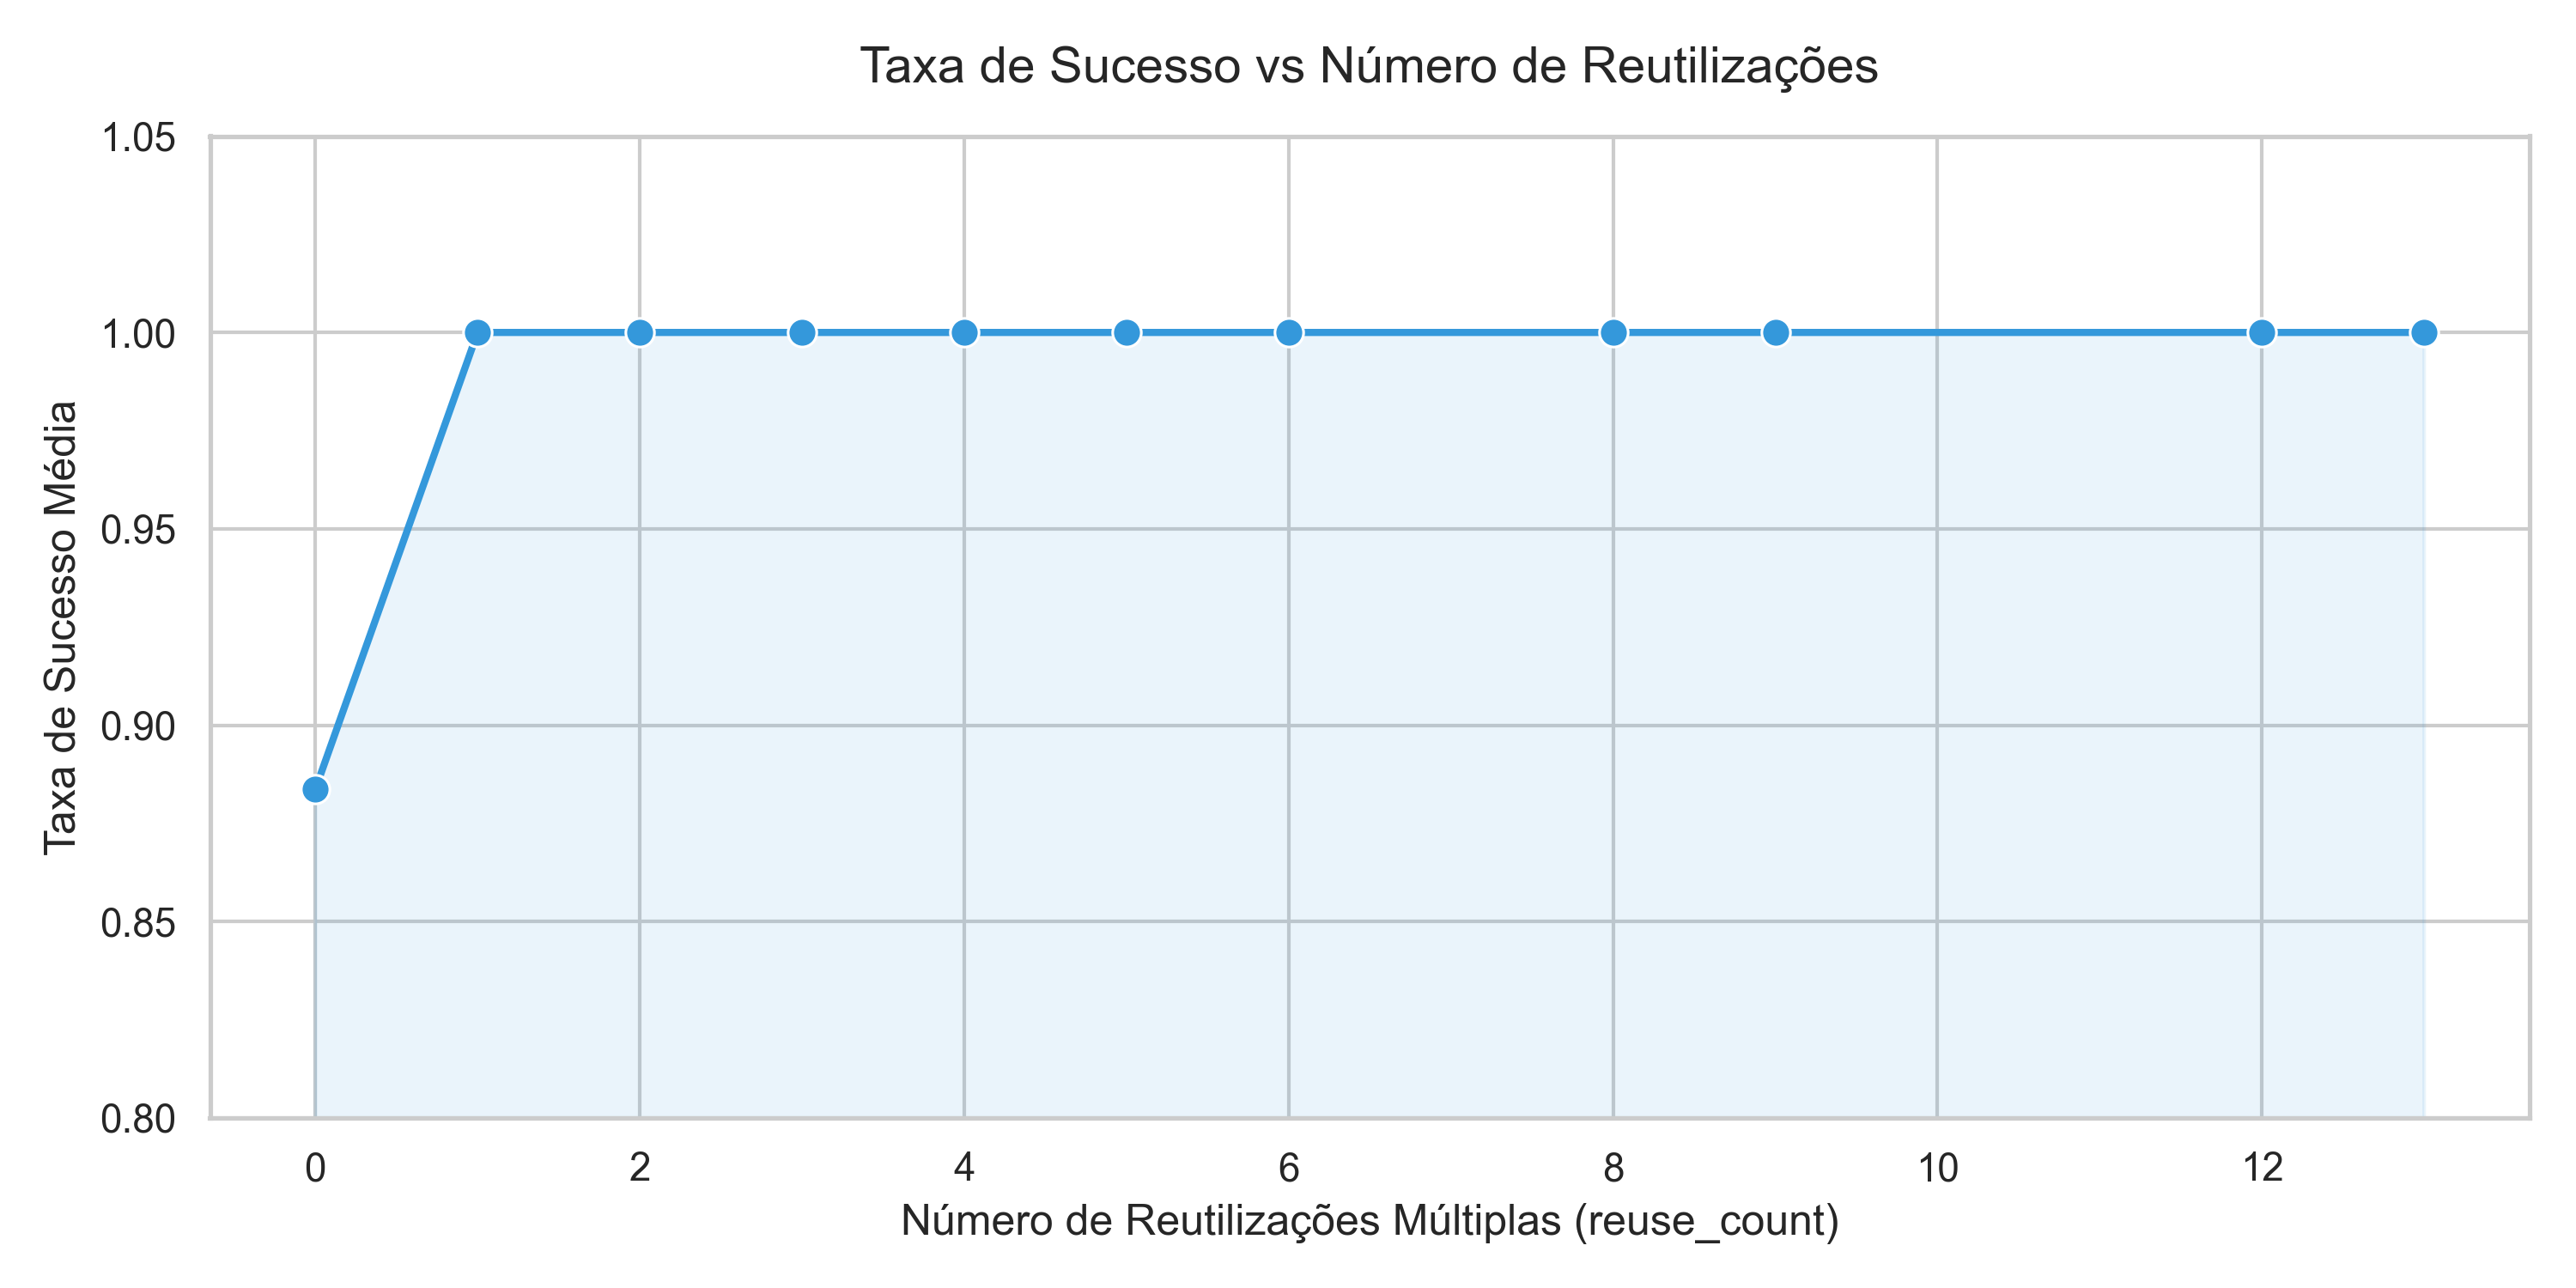

In [4]:
kaio_stats = pd.read_csv('../data/kaio_reusability_stats.csv')
display(Markdown('### Comparação: Virgens vs Reutilizados'))
display(kaio_stats)

kaio_yearly = pd.read_csv('../data/kaio_reusability_yearly_stats.csv')
display(Markdown('### Taxa de Sucesso Anual por Tipo'))
display(kaio_yearly)

display(Markdown('### Taxa de Sucesso Global'))
display(Image(filename='../graphs/kaio_overall_success_rate.png', width=700))

display(Markdown('### Distribuição Temporal'))
display(Image(filename='../graphs/kaio_temporal_distribution.png', width=700))

display(Markdown('### Curva Dose-Resposta'))
display(Image(filename='../graphs/kaio_dose_response.png', width=700))

### O que os dados mostram

O resultado mais marcante: dos 149 voos com boosters reutilizados, **nenhum falhou**. Já entre os 43 voos com boosters virgens, 5 falharam (taxa de 88,37%). A diferença é de 11,63 pontos percentuais a favor dos reutilizados.

Quando o Kaio fez o controle temporal (olhando ano a ano), ficou claro que as falhas dos virgens estão concentradas nos primeiros anos do programa. A partir de 2016, quando os boosters reutilizados começaram a aparecer, ambos os grupos passaram a ter desempenho excelente.

Mas vale ter cuidado com essa leitura. Os boosters reutilizados só existem a partir de 2016, quando a SpaceX já tinha bastante experiência acumulada. Além disso, existe um viés de seleção natural: boosters que apresentam problemas simplesmente não são candidatos à reutilização.

---

## 4. Experiência do Booster — Izac

O Izac aprofundou a análise do Kaio: em vez de só separar "virgem vs reutilizado", ele criou faixas de experiência para ver se existe algum padrão de degradação conforme o booster acumula mais voos.

### Taxa de Sucesso por Nível de Experiência

,experience_level,count,mean,success_rate (%)
0,Novatos (0),43,0.883721,88.372093
1,Intermediários (1-3),50,1.000000,100.000000
2,Experientes (4-6),30,1.000000,100.000000
3,Veteranos (7+),69,1.000000,100.000000


### Experiência vs Sucesso

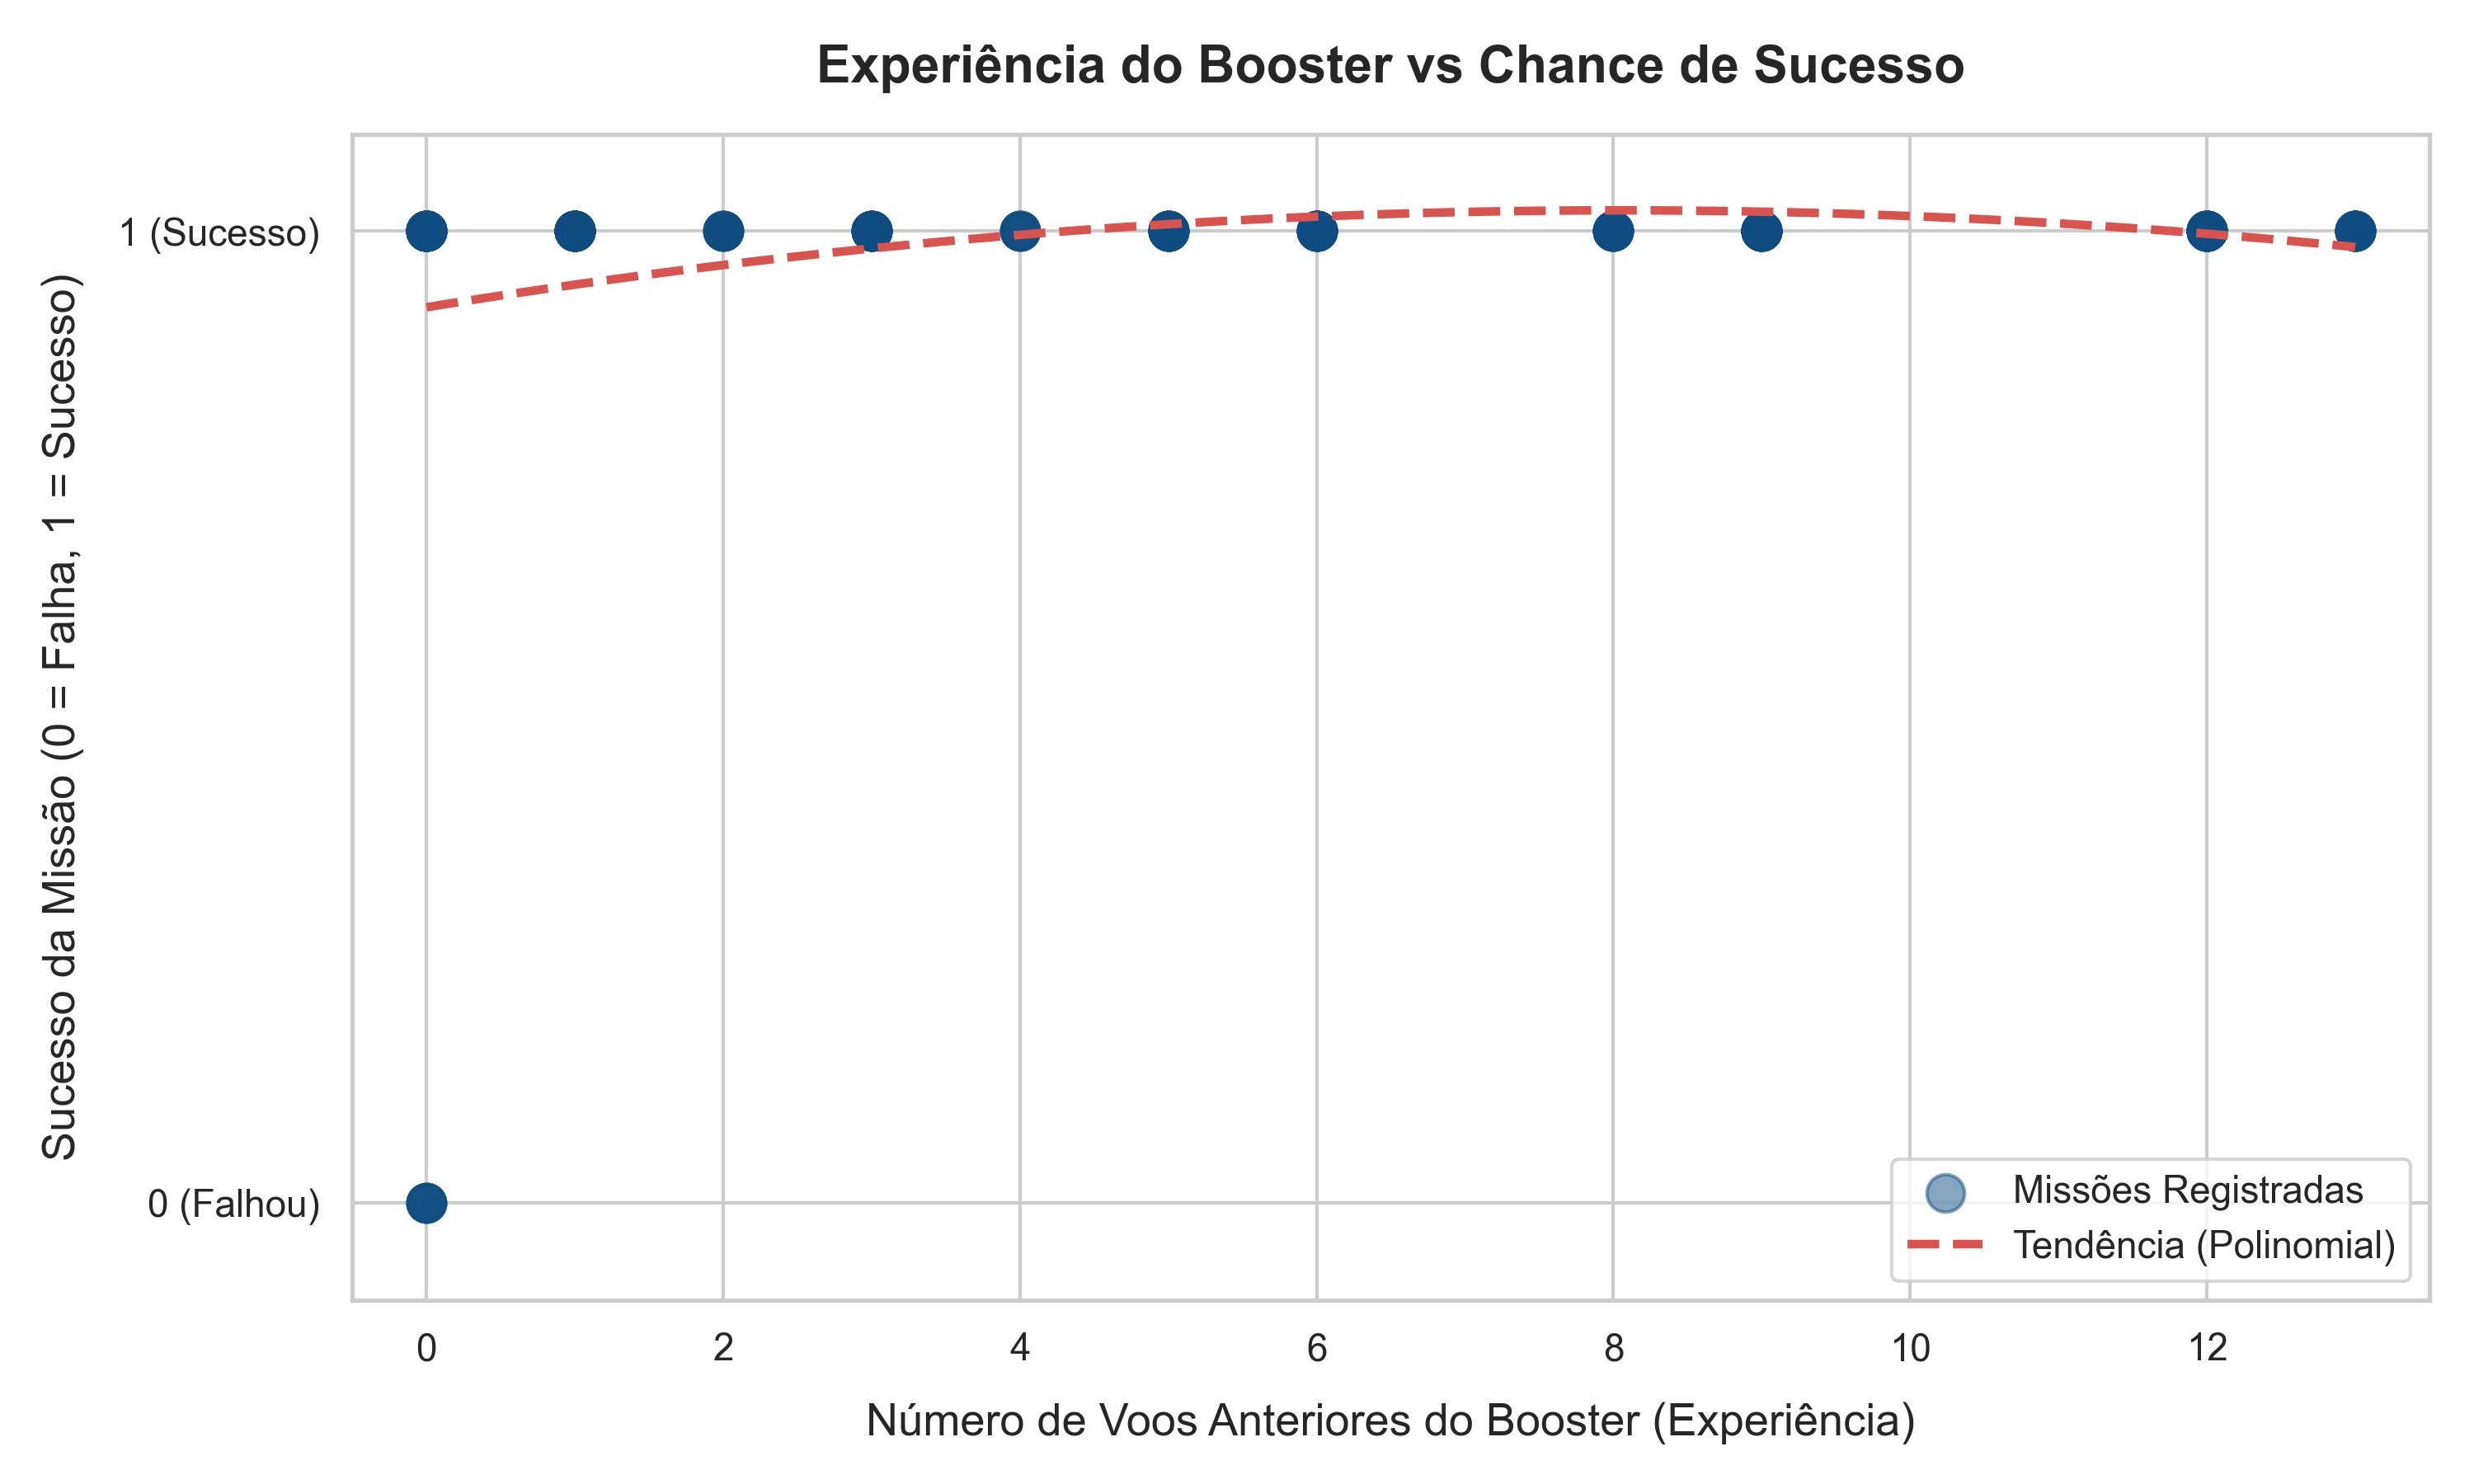

### Distribuição de Reutilização

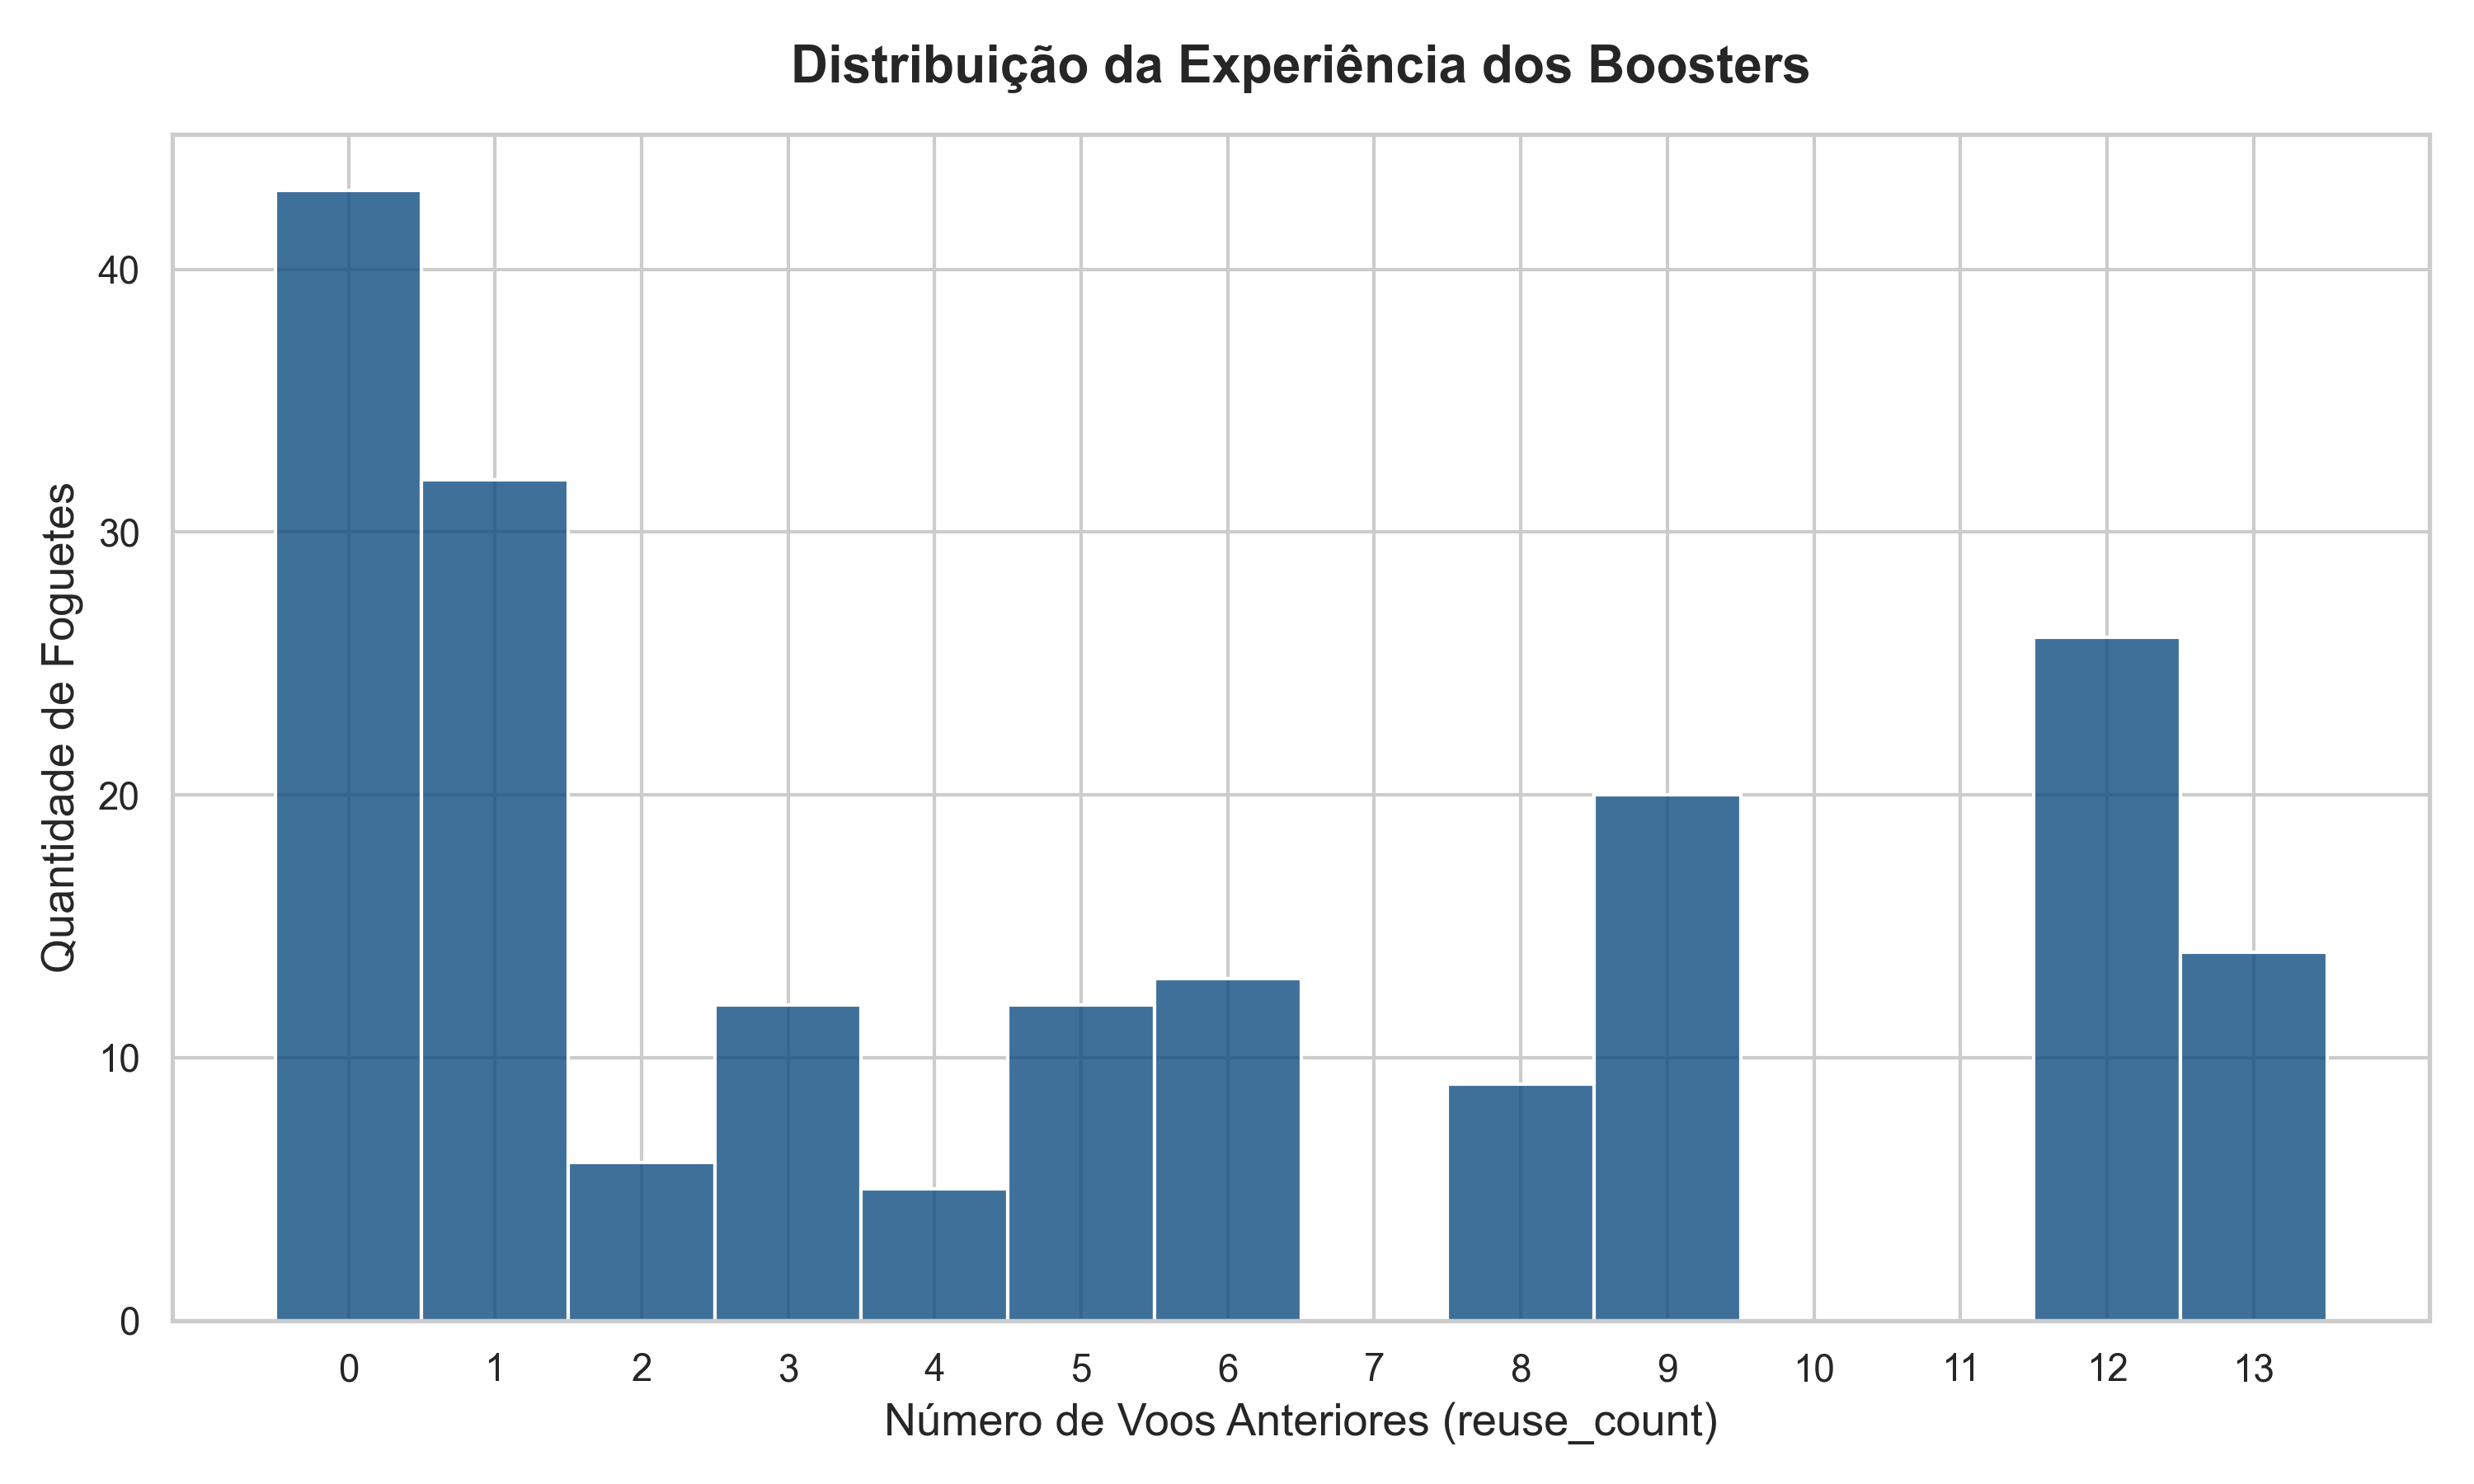

### Sucesso por Nível de Experiência

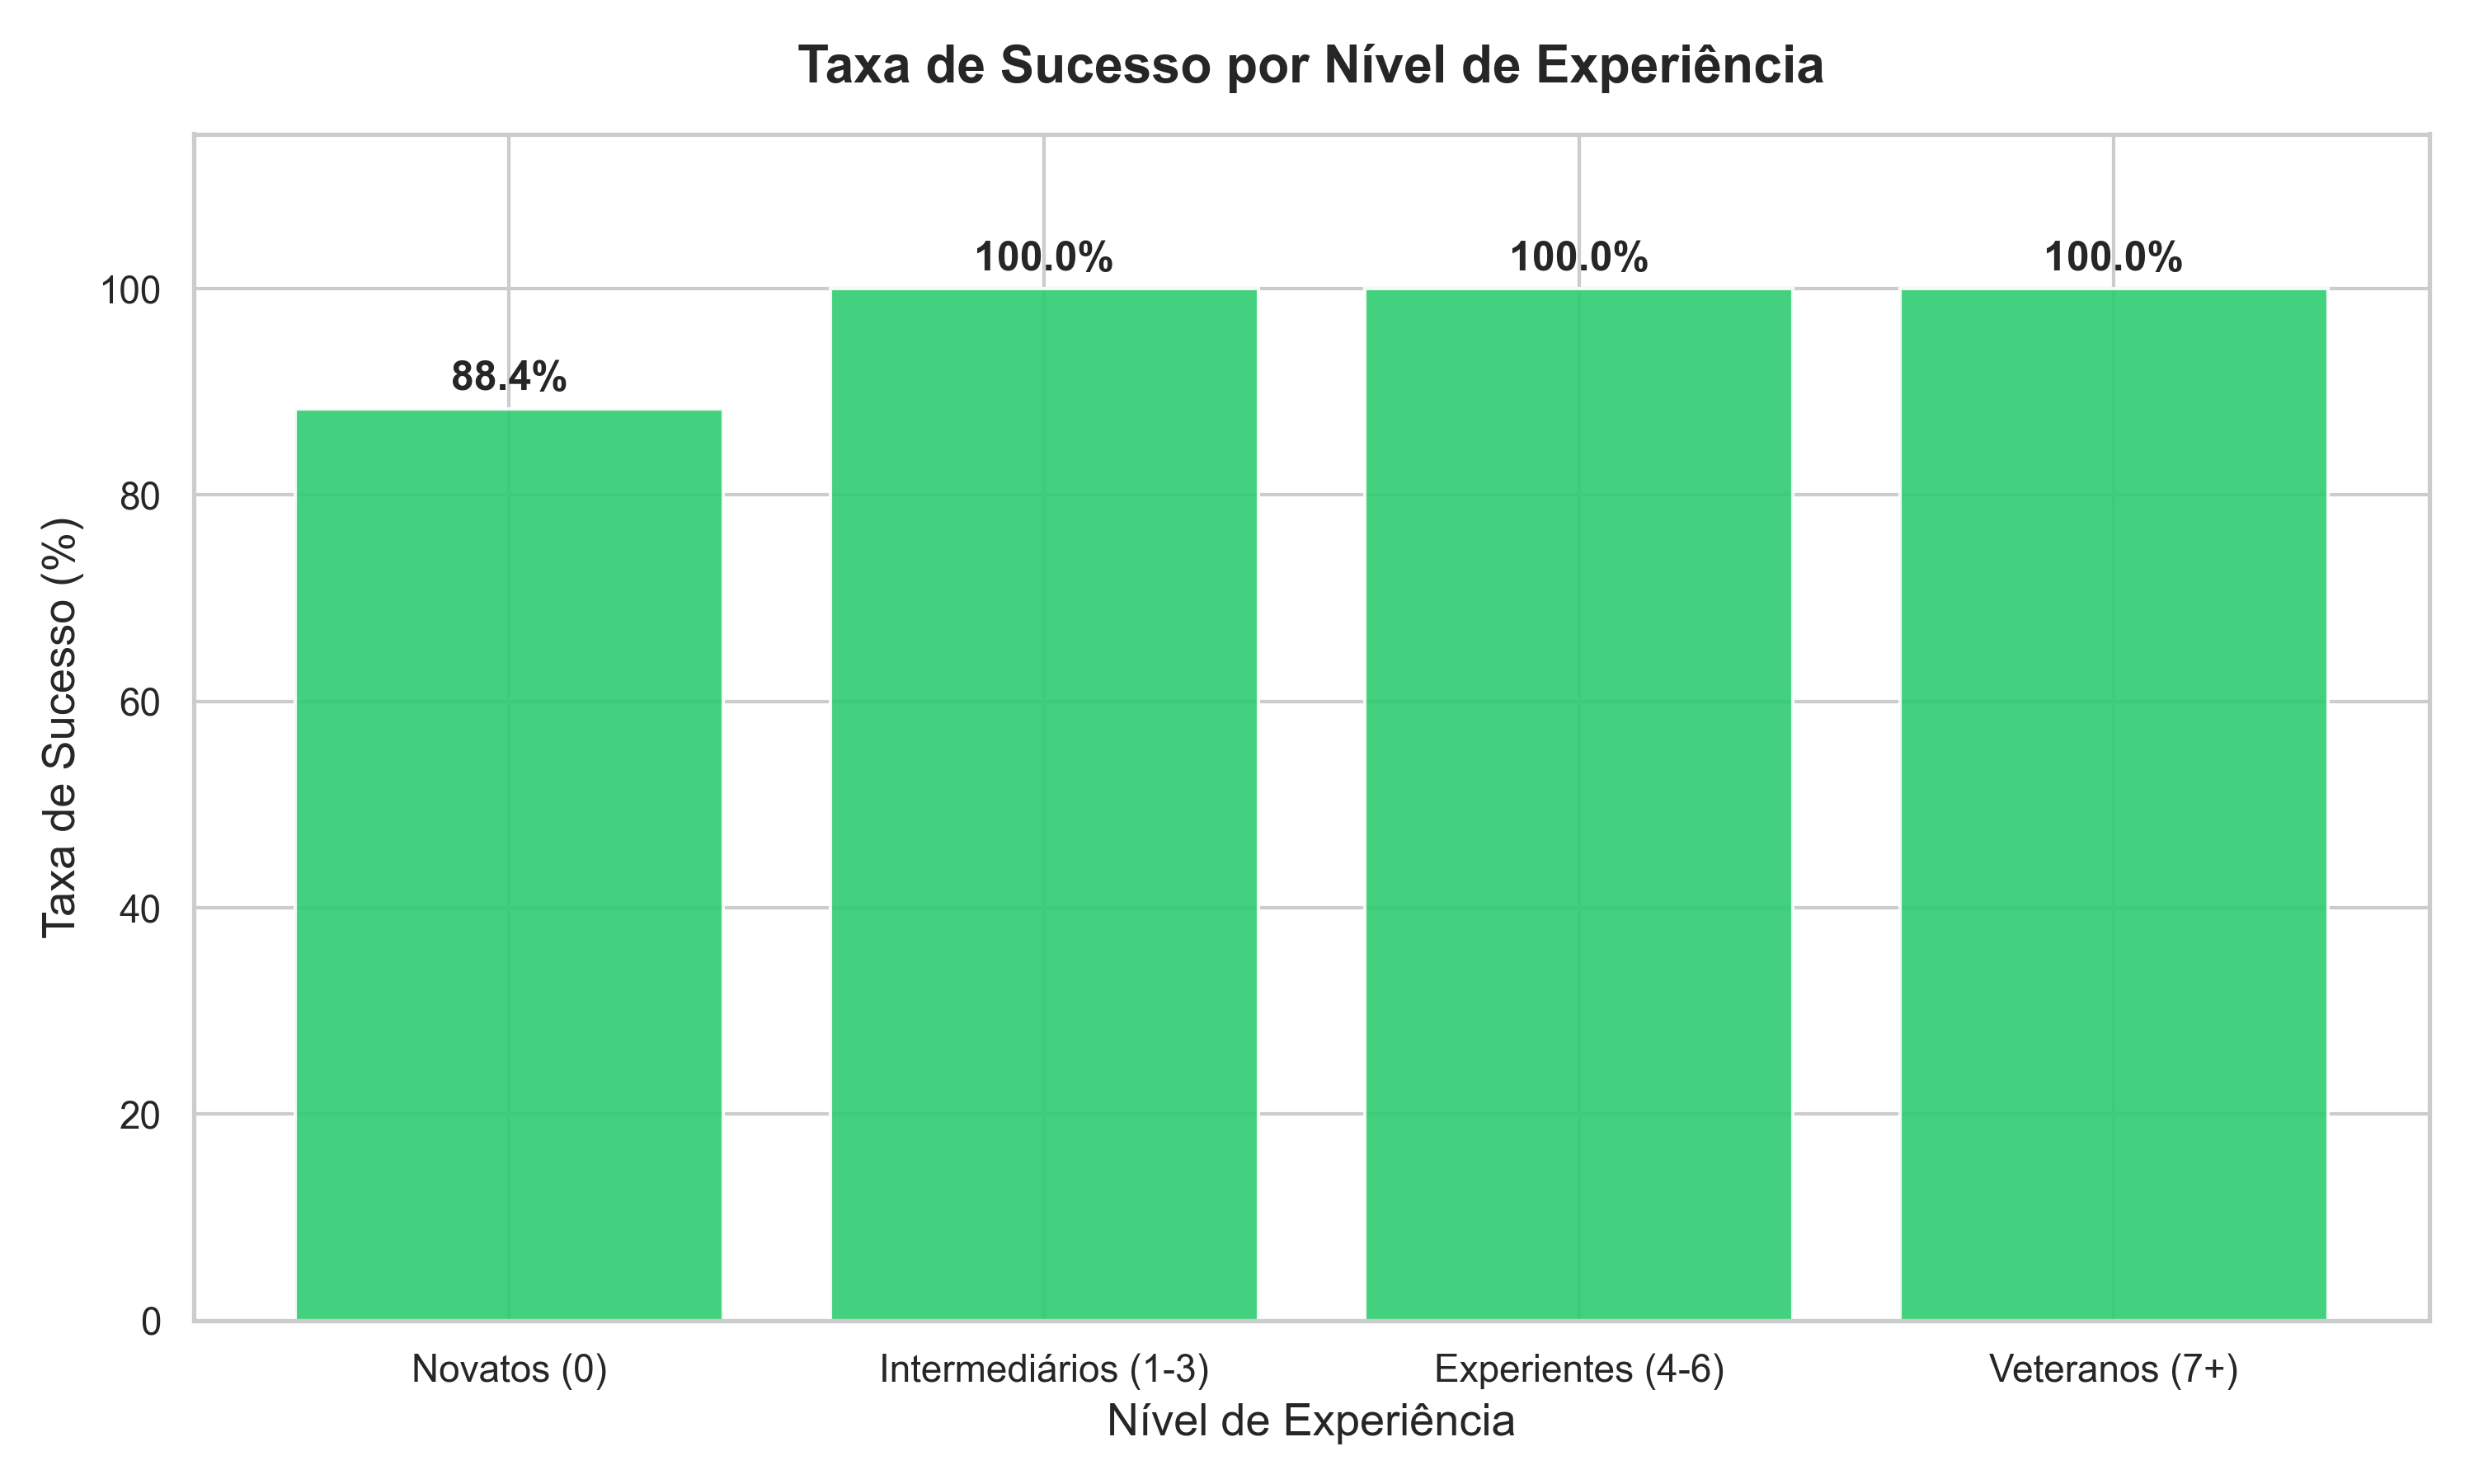

In [5]:
izac_stats = pd.read_csv('../analyses/izac/experience_stats.csv')
display(Markdown('### Taxa de Sucesso por Nível de Experiência'))
display(izac_stats)

display(Markdown('### Experiência vs Sucesso'))
display(Image(filename='../graphs/izac_experience_vs_success.png', width=700))

display(Markdown('### Distribuição de Reutilização'))
display(Image(filename='../graphs/izac_reuse_distribution.png', width=700))

display(Markdown('### Sucesso por Nível de Experiência'))
display(Image(filename='../graphs/izac_success_by_experience.png', width=700))

### O que os dados mostram

O padrão que aparece é bem claro e até surpreendente: boosters no seu primeiro voo têm taxa de sucesso de 88,37%. Mas a partir do segundo voo, a taxa vai a 100% — e se mantém assim para todas as faixas, incluindo boosters veteranos com 7 ou mais voos.

Isso sugere que o primeiro voo funciona quase como um "teste de qualidade natural": se o booster sobrevive ao primeiro lançamento e é recuperado com sucesso, ele tende a continuar funcionando nas próximas vezes. Não aparece nenhum sinal de desgaste, mesmo em boosters que já voaram 13 vezes.

Agora, é justo considerar que parte disso pode ser survivorship bias — boosters que teriam problemas em voos futuros podem já ter sido retirados de operação por outros motivos que não estão nos nossos dados.

---

## 5. Famílias de Foguetes — Jonatas

O Jonatas comparou a confiabilidade das três famílias de foguetes que a SpaceX operou: Falcon 1, Falcon 9 e Falcon Heavy.

### Confiabilidade por Família de Foguete

,rocket_name,Total,Sucessos,Taxa Sucesso
0,Falcon 1,5,2,0.4000
1,Falcon 9,178,176,0.9888
2,Falcon Heavy,9,9,1.0000


### Taxa de Sucesso por Família

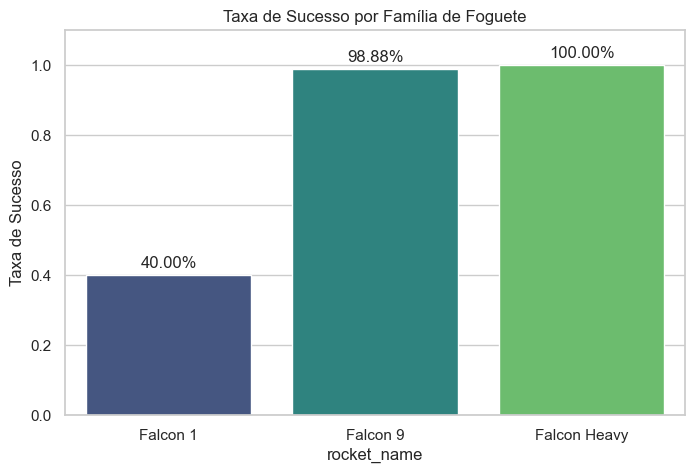

### Distribuição Temporal de Lançamentos

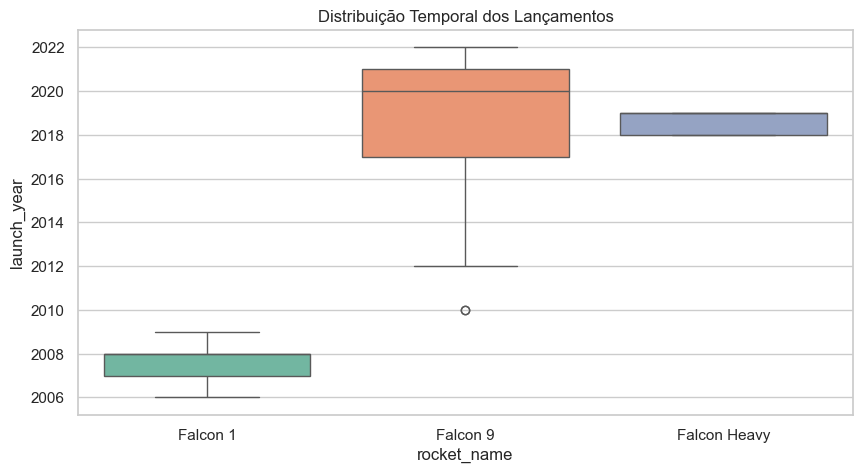

### Evolução Temporal do Sucesso

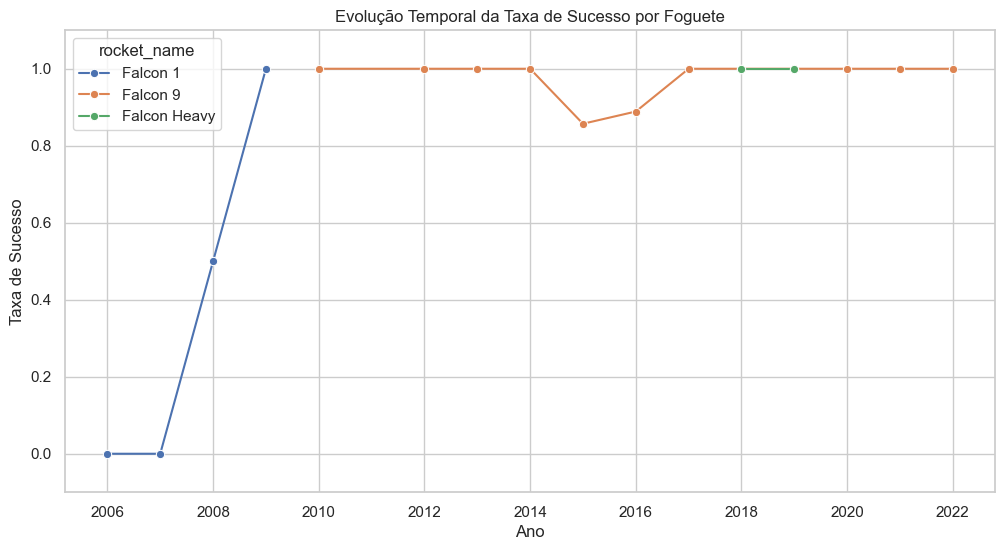

In [6]:
jonatas_stats = pd.read_csv('../analyses/jonatas/rocket_stats.csv')
display(Markdown('### Confiabilidade por Família de Foguete'))
display(jonatas_stats)

display(Markdown('### Taxa de Sucesso por Família'))
display(Image(filename='../graphs/jonatas_taxa_sucesso_familia.png', width=700))

display(Markdown('### Distribuição Temporal de Lançamentos'))
display(Image(filename='../graphs/jonatas_distribuicao_temporal_lancamentos.png', width=700))

display(Markdown('### Evolução Temporal do Sucesso'))
display(Image(filename='../graphs/jonatas_evolucao_temporal_sucesso.png', width=700))

### O que os dados mostram

A diferença entre as gerações é gritante. O Falcon 1, que foi o primeiro foguete da SpaceX (2006-2009), conseguiu apenas 40% de sucesso — acertou 2 de 5. O Falcon 9 já está em outro patamar, com 98,9% em 178 registros. E o Falcon Heavy tem 100%, mas com apenas 9 registros.

O Falcon 9 é de longe o mais relevante estatisticamente, pelo volume de dados que temos. O Falcon Heavy tem resultado perfeito, mas com amostra tão pequena fica difícil tirar conclusões fortes. E o Falcon 1 é praticamente de outra empresa — a SpaceX de 2006 e a de 2018 são realidades completamente diferentes em termos de experiência e tecnologia.

---

## 6. Síntese dos Resultados

Juntando tudo, a tabela abaixo resume o que cada análise encontrou:

In [7]:
synthesis = pd.DataFrame({
    'Análise': [
        'Temporal (Gabriel)',
        'Reutilização (Kaio)',
        'Experiência (Izac)',
        'Famílias (Jonatas)'
    ],
    'Principal Achado': [
        'Sucesso evoluiu de 0% (2006) para 100% (2017-2022)',
        'Reutilizados: 100% vs Virgens: 88,4% (+11,6 pp)',
        'Após 1º voo, 100% de sucesso em todas as faixas',
        'Falcon 9: 98,9% | Falcon Heavy: 100% | Falcon 1: 40%'
    ],
    'Evidência': [
        'Tendência crescente; IC 95% por ano',
        'n=43 virgens, n=149 reutilizados',
        'Novatos: 88,4% (n=43), demais: 100% (n=149)',
        'Diferença significativa entre famílias'
    ],
    'Confundidor': [
        'Mudança de família de foguete',
        'Viés temporal + viés de seleção',
        'Survivorship bias',
        'Tamanhos amostrais desiguais'
    ]
})

display(synthesis)

,Análise,Principal Achado,Evidência,Confundidor
0,Temporal (Gabriel),Sucesso evoluiu de 0% (2006) para 100% (2017-2...,Tendência crescente; IC 95% por ano,Mudança de família de foguete
1,Reutilização (Kaio),"Reutilizados: 100% vs Virgens: 88,4% (+11,6 pp)","n=43 virgens, n=149 reutilizados",Viés temporal + viés de seleção
2,Experiência (Izac),"Após 1º voo, 100% de sucesso em todas as faixas","Novatos: 88,4% (n=43), demais: 100% (n=149)",Survivorship bias
3,Famílias (Jonatas),"Falcon 9: 98,9% | Falcon Heavy: 100% | Falcon ...",Diferença significativa entre famílias,Tamanhos amostrais desiguais


---

## 7. Limitações

Antes de tirar conclusões, é preciso reconhecer as limitações deste estudo.

O **viés temporal** é provavelmente o mais importante: como a reutilização só começou em 2016, ela coincide com o período em que a SpaceX já tinha amadurecido bastante. Fica difícil separar o que é efeito da reutilização em si do que é simplesmente a empresa ficando melhor com o tempo.

O **viés de seleção** também pesa: boosters com defeitos não chegam a ser reutilizados, então o grupo "reutilizado" já vem pré-filtrado com boosters que provaram funcionar. Isso infla a taxa de sucesso desse grupo de forma natural.

Além desses, os tamanhos de amostra são muito desiguais (Falcon 1 com 5 registros vs Falcon 9 com 178), a variável `success` é binária e não captura nuances como sucessos parciais, e o dataset cobre apenas até 2022.

---

## 8. Conclusão

Voltando à pergunta original — *a reutilização de foguetes afeta a confiabilidade das missões?* — os dados apontam que não, pelo menos não de forma negativa.

Na verdade, o que observamos foi o oposto: boosters reutilizados tiveram taxa de sucesso de 100% (149 de 149), enquanto os virgens ficaram em 88,37% (38 de 43). Não encontramos nenhum sinal de desgaste mesmo em boosters com 13 voos anteriores. A SpaceX como um todo melhorou muito ao longo dos anos, saindo de 0% de sucesso em 2006 para 100% sustentado a partir de 2017, e isso acompanhou tanto a evolução dos foguetes (Falcon 1 para Falcon 9 para Falcon Heavy) quanto a adoção crescente da reutilização.

Dito isso, não dá para afirmar com certeza que a reutilização *causa* mais confiabilidade. Os confundidores temporais e o viés de seleção são reais e precisam ser levados em conta. O que podemos dizer com segurança é que não encontramos evidência de que reutilizar boosters prejudique as missões — e isso, por si só, já é uma informação relevante para a viabilidade do modelo de reusabilidade.

---

*Equipe SpaceX Reliability Study — Junho 2026*